# SVG Report Rendering Demo — `vfairness.rendering`

This notebook demonstrates **all 43 SVG templates** in the vfairness rendering system.
Each template is a Jinja2-powered SVG that turns analysis results into publication-ready,
card-based dashboards.

The templates are organised into nine categories:

| Category | Templates | Description |
|---|---|---|
| **Report Dashboards** | 4 | Full audit / analysis reports (Bias Audit, Calibration, Fairness, CI/CD) |
| **Fairness Metrics** | 6 | Radar chart, heatmap, bar chart, group comparison, effect sizes, CIs |
| **Calibration** | 4 | Reliability diagram, group calibration, disparity, Pareto frontier |
| **Feature Engineering** | 5 | Correlation heatmap, correlation matrix, proxy risk, transformation, intersectional |
| **Training** | 4 | Training report, full analysis, method comparison, trade-off scatter |
| **Post-Processing** | 3 | Threshold optimisation, reweighting comparison, detailed fairness report |
| **Monitoring** | 4 | Live dashboard, drift report, alert timeline, temporal trends |
| **Experimentation** | 4 | A/B results, recommendation, power analysis, causal decomposition |
| **Workflow Integration** | 3 | Workflow overview, hierarchical gate, report card |
| **Advanced Modules** | 6 | Robustness, ranking, validation, discovery, regression, reporting dashboard |

**Requirements:** `pip install jinja2 numpy pandas`

In [ ]:
import sys, importlib, os, warnings
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
from types import SimpleNamespace
from datetime import datetime, timedelta
from IPython.display import SVG, display
warnings.filterwarnings('ignore')
np.random.seed(42)

# Force-reload rendering to pick up any recent changes
for key in list(sys.modules.keys()):
    if key.startswith('vfairness.rendering'):
        del sys.modules[key]

from vfairness.rendering import (
    list_templates,
    # Report dashboards
    bias_audit_to_svg, calibration_report_to_svg,
    fairness_report_to_svg, cicd_pipeline_to_svg,
    # Fairness metrics
    radar_chart_to_svg, disparity_heatmap_to_svg,
    metrics_bar_chart_to_svg, group_comparison_to_svg,
    effect_sizes_to_svg, confidence_intervals_to_svg,
    # Calibration
    reliability_diagram_to_svg, group_calibration_to_svg,
    calibration_disparity_to_svg, pareto_frontier_to_svg,
    # Feature engineering
    correlation_heatmap_to_svg, correlation_matrix_to_svg, proxy_risk_to_svg,
    transformation_comparison_to_svg, intersectional_analysis_to_svg,
    # Training
    training_report_to_svg, training_analysis_report_to_svg,
    method_comparison_to_svg, tradeoff_analysis_to_svg,
    # Post-processing
    threshold_optimization_to_svg, reweighting_comparison_to_svg,
    fairness_detailed_report_to_svg,
    # Monitoring
    monitoring_dashboard_to_svg, drift_report_to_svg,
    alert_timeline_to_svg, temporal_analysis_to_svg,
    # Experimentation & A/B Testing
    experiment_results_to_svg, experiment_recommendation_to_svg,
    power_analysis_to_svg, causal_decomposition_to_svg,
    # Workflow Integration
    workflow_overview_to_svg, hierarchical_gate_to_svg,
    report_card_to_svg,
    # Advanced modules
    robustness_testing_to_svg, ranking_fairness_to_svg,
    data_validation_to_svg, auto_discovery_to_svg,
    regression_fairness_to_svg, reporting_dashboard_to_svg,
)
from vfairness.explainer import FairnessExplainer

templates = list_templates()
print(f'Available SVG templates: {len(templates)}')
for t in templates:
    print(f'  - {t}')
print('\nSetup complete (FairnessExplainer loaded for explanation demos)')

In [2]:
# ── Shared synthetic data used across multiple templates ──

n = 2000
race = np.random.choice(['White', 'Black', 'Hispanic', 'Asian'], n, p=[0.60, 0.15, 0.18, 0.07])
gender = np.random.choice(['Male', 'Female', 'Non-binary'], n, p=[0.72, 0.22, 0.06])
income = np.random.lognormal(10.8, 0.5, n).astype(int)
credit_score = np.clip(np.random.normal(700, 50, n), 300, 850).astype(int)

# Biased outcome for demonstration purposes
bias = np.where(race == 'White', 0.12, -0.08) + np.where(gender == 'Male', 0.07, -0.03)
base_prob = 0.5 + (credit_score - 650) / 600 + bias
loan_approved = (np.random.rand(n) < np.clip(base_prob, 0.05, 0.95)).astype(int)

df = pd.DataFrame({
    'race': race, 'gender': gender,
    'income': income, 'credit_score': credit_score,
    'loan_approved': loan_approved,
})

# Fairness classification data
n_fair = 1000
fair_gender = np.random.choice(['Male', 'Female'], n_fair, p=[0.55, 0.45])
y_true = np.random.binomial(1, 0.6, n_fair)
fair_bias = np.where(fair_gender == 'Male', 0.15, -0.05)
prob = np.clip(0.5 + fair_bias + 0.2 * y_true + np.random.normal(0, 0.1, n_fair), 0, 1)
y_pred = (prob > 0.5).astype(int)

# Calibration data
n_cal = 1000
cal_y_true = np.random.randint(0, 2, n_cal)
cal_y_prob = np.clip(cal_y_true * 0.6 + np.random.normal(0.3, 0.15, n_cal), 0, 1)
cal_protected = np.random.choice(['Group A', 'Group B', 'Group C'], n_cal)

print(f'Lending dataset: {df.shape[0]} rows')
print(f'Fairness dataset: {n_fair} samples, approval rate {y_pred.mean():.1%}')
print(f'Calibration dataset: {n_cal} samples, 3 groups')

Lending dataset: 2000 rows
Fairness dataset: 1000 samples, approval rate 84.2%
Calibration dataset: 1000 samples, 3 groups


---
## Report Dashboards

Full-page audit and analysis reports produced from vfairness core modules.

### 1 — Bias Audit Report (`bias_audit`)

**What it shows:** A comprehensive multi-module bias audit. The SVG displays an overall risk
score badge (percentage), module-level risk cards (Historical, Representation, Statistical,
Proxy), a critical-issues table with severity badges, representation bars comparing dataset
vs population benchmark proportions, and actionable recommendations.

**When to use:** After running `BiasDetector.full_audit()` to get a complete picture of
potential biases in a dataset.

bias_audit (with explanation) — 20,426 bytes


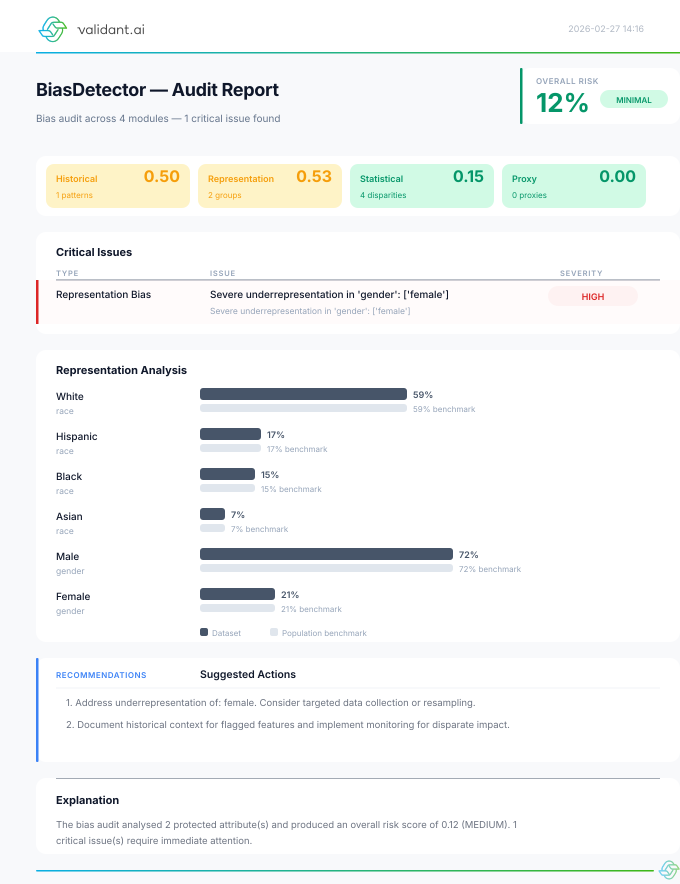

In [3]:
from vfairness.preprocessing.bias_detection import BiasDetector

benchmarks = {
    'gender': {'Male': 0.49, 'Female': 0.51, 'Non-binary': 0.03},
    'race': {'White': 0.58, 'Black': 0.13, 'Hispanic': 0.19, 'Asian': 0.06},
}
detector = BiasDetector(
    df, protected_attributes=['race', 'gender'],
    outcome_column='loan_approved', benchmarks=benchmarks,
)
report = detector.full_audit(
    include_historical=True, include_representation=True,
    include_disparities=True, include_proxies=True,
)

# Use FairnessExplainer to generate a contextual explanation
expl = FairnessExplainer.explain(report)
svg = bias_audit_to_svg(report, explanation=expl.summary)
print(f'bias_audit (with explanation) — {len(svg):,} bytes')
display(SVG(data=svg))

### 2 — Calibration Report (`calibration_report`)

**What it shows:** An overall calibration dashboard with ECE / MCE / Brier score badges,
per-group calibration metrics in coloured cards, a disparity analysis panel (best vs worst
group), critical issues, and a recommended calibration strategy.

**When to use:** After running `CalibrationAnalyzer.full_analysis()` to evaluate how well
predicted probabilities match observed frequencies, both overall and across groups.

calibration_report — 17,559 bytes


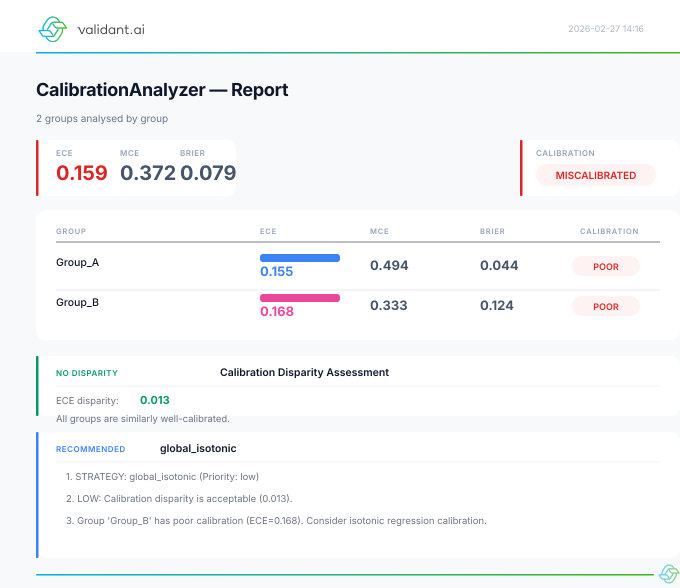

In [4]:
from vfairness.post_processing.calibration import CalibrationAnalyzer

# Calibration data with per-group miscalibration
n_c = 2000
pa = np.random.choice(['Group_A', 'Group_B'], n_c, p=[0.6, 0.4])
yt = np.random.binomial(1, 0.4, n_c)
yp = np.zeros(n_c)
mask_a = pa == 'Group_A'
yp[mask_a] = np.clip(yt[mask_a] * 0.8 + np.random.normal(0.2, 0.15, mask_a.sum()), 0.01, 0.99)
yp[~mask_a] = np.clip(yt[~mask_a] * 0.5 + np.random.normal(0.35, 0.2, (~mask_a).sum()), 0.01, 0.99)

cal_analyzer = CalibrationAnalyzer(
    y_true=yt, y_prob=yp, protected_attr=pa,
    attribute_name='group', n_bins=10, min_group_size=50,
)
cal_report = cal_analyzer.full_analysis(
    include_tradeoffs=True, include_recommendation=True,
    include_brier_decomposition=True,
)
svg = cal_report.to_svg()
print(f'calibration_report — {len(svg):,} bytes')
display(SVG(data=svg))

### 3 — Fairness Metric Dashboard (`fairness_report`)

**What it shows:** A metric card grid where each fairness metric (Demographic Parity,
Equal Opportunity, Equalized Odds, etc.) appears as a card with its value, threshold,
and a FAIR/UNFAIR badge. Below the cards, per-group positive-rate bars compare outcome
rates across demographic groups. An overall fairness score and summary text appear at the top.

**When to use:** After running `FairnessAnalyzer.get_report()` for a quick pass/fail
overview of all fairness metrics.

fairness_report (with explanation) — 19,710 bytes


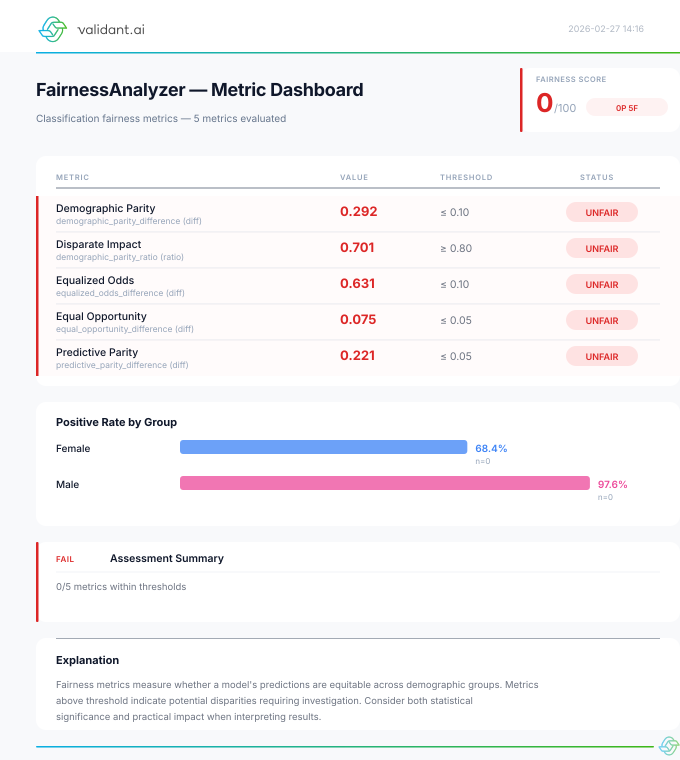

In [5]:
from vfairness import FairnessAnalyzer

fair_analyzer = FairnessAnalyzer(y_true, y_pred, fair_gender)
fair_report = fair_analyzer.get_report()

svg = fairness_report_to_svg(
    fair_report,
    explanation=(
        "Fairness metrics measure whether a model's predictions are equitable across "
        "demographic groups. Metrics above threshold indicate potential disparities "
        "requiring investigation. Consider both statistical significance and practical "
        "impact when interpreting results."
    ),
)
print(f'fairness_report (with explanation) — {len(svg):,} bytes')
display(SVG(data=svg))

### 4 — CI/CD Pipeline Gate Report (`cicd_pipeline`)

**What it shows:** A pipeline-style report with three sections: data validation results
(errors/warnings), fairness test results (each test with metric value, threshold, and
PASS/FAIL badge), and the final gate decision (APPROVED / REJECTED) with blocking reasons
and warnings.

**When to use:** In automated CI/CD pipelines to produce an auditable SVG artefact that
records why a model was approved or rejected.

cicd_pipeline — 18,628 bytes


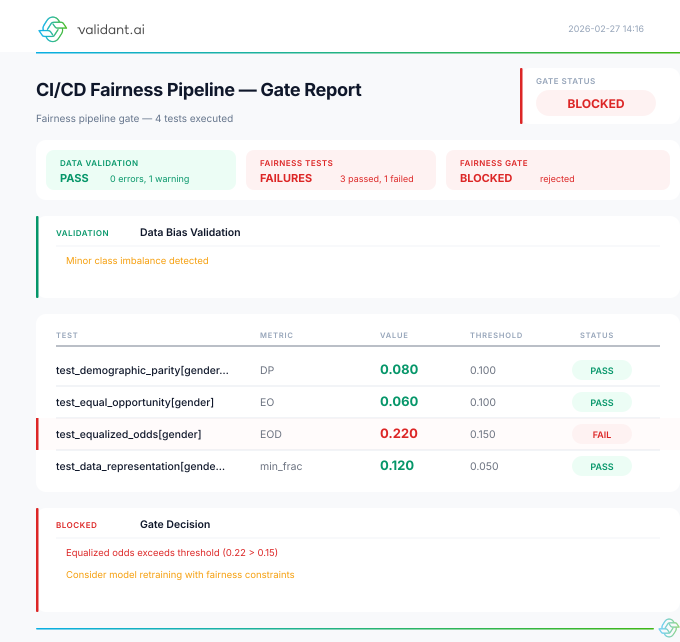

In [6]:
from enum import Enum

class Status(Enum):
    passed = 'passed'
    failed = 'failed'

class GateStatus(Enum):
    approved = 'approved'
    rejected = 'rejected'

validation = SimpleNamespace(
    passed=True, errors=[],
    warnings=[SimpleNamespace(message='Minor class imbalance detected',
                              severity=SimpleNamespace(value='warning'))],
)
tests = [
    SimpleNamespace(test_name='test_demographic_parity[gender]', status=Status.passed,
                    metric_name='DP', metric_value=0.08, threshold=0.10),
    SimpleNamespace(test_name='test_equal_opportunity[gender]', status=Status.passed,
                    metric_name='EO', metric_value=0.06, threshold=0.10),
    SimpleNamespace(test_name='test_equalized_odds[gender]', status=Status.failed,
                    metric_name='EOD', metric_value=0.22, threshold=0.15),
    SimpleNamespace(test_name='test_data_representation[gender]', status=Status.passed,
                    metric_name='min_frac', metric_value=0.12, threshold=0.05),
]
gate = SimpleNamespace(
    status=GateStatus.rejected, approved=False,
    blocking_reasons=['Equalized odds exceeds threshold (0.22 > 0.15)'],
    warnings=['Consider model retraining with fairness constraints'],
)

svg = cicd_pipeline_to_svg(validation_result=validation, test_results=tests, gate_decision=gate)
print(f'cicd_pipeline — {len(svg):,} bytes')
display(SVG(data=svg))

---
## Fairness Metrics Visualizations

Six chart types for visualising fairness metrics from `FairnessAnalyzer`.

### 5 — Radar Chart (`radar_chart`)

**What it shows:** A spider / polygon chart where each spoke represents one fairness metric
(Demographic Parity, Equal Opportunity, etc.). The filled polygon shows observed values;
a dashed polygon shows the configured thresholds. Dots on spokes mark exact values.
A status badge (Fair / Marginal / Unfair) summarises the overall assessment.

**When to use:** To get an at-a-glance multi-metric fairness profile.

radar_chart (with explanation) — 16,810 bytes


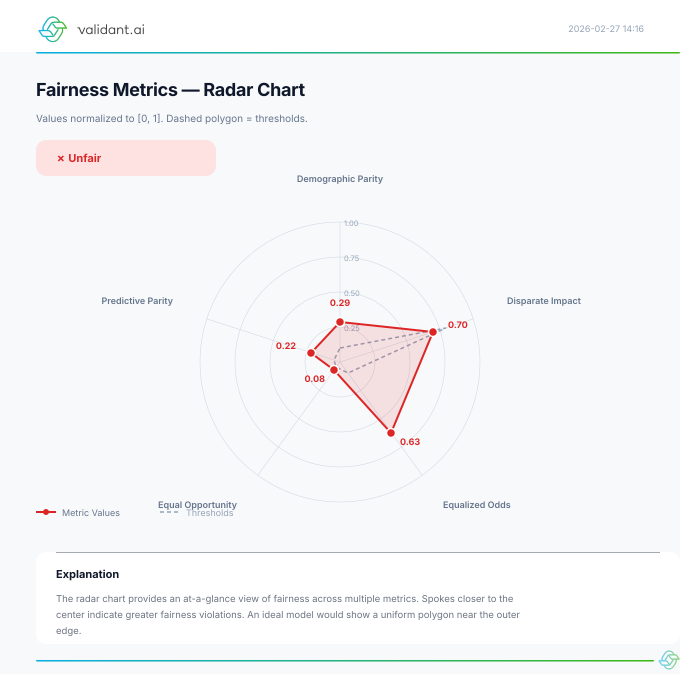

In [7]:
svg = radar_chart_to_svg(
    fair_report,
    explanation=(
        "The radar chart provides an at-a-glance view of fairness across multiple metrics. "
        "Spokes closer to the center indicate greater fairness violations. An ideal model "
        "would show a uniform polygon near the outer edge."
    ),
)
print(f'radar_chart (with explanation) — {len(svg):,} bytes')
display(SVG(data=svg))

### 6 — Disparity Heatmap (`disparity_heatmap`)

**What it shows:** A coloured heatmap grid with demographic groups on rows and fairness
metrics on columns. Cell colours range from green (low disparity) through yellow to
red (high disparity). A summary badge indicates the overall disparity level.

**When to use:** When you need to compare multiple metrics across multiple groups
simultaneously and quickly spot the most problematic intersections.

disparity_heatmap — 15,932 bytes


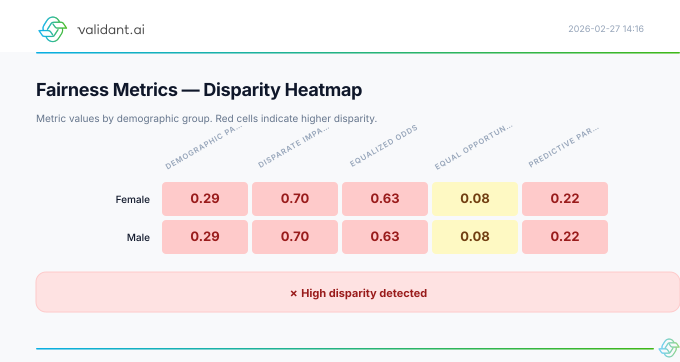

In [8]:
svg = disparity_heatmap_to_svg(fair_report)
print(f'disparity_heatmap — {len(svg):,} bytes')
display(SVG(data=svg))

### 7 — Metrics Bar Chart (`metrics_bar_chart`)

**What it shows:** Horizontal bars for each fairness metric. Bar length indicates the
metric value; a dashed red vertical line marks the fairness threshold. Each bar has
a FAIR/FAIL badge. A summary header shows how many metrics passed vs failed.

**When to use:** For a simple, linear comparison of metric values against their thresholds.

metrics_bar_chart (with explanation) — 18,117 bytes


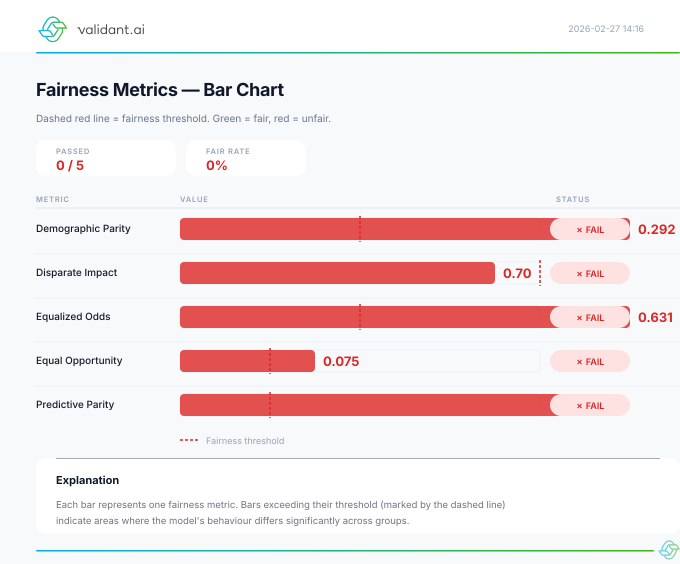

In [9]:
svg = metrics_bar_chart_to_svg(
    fair_report,
    explanation=(
        "Each bar represents one fairness metric. Bars exceeding their threshold "
        "(marked by the dashed line) indicate areas where the model's behaviour "
        "differs significantly across groups."
    ),
)
print(f'metrics_bar_chart (with explanation) — {len(svg):,} bytes')
display(SVG(data=svg))

### 8 — Group Comparison (`group_comparison`)

**What it shows:** Per-group horizontal bars for a single metric (e.g. positive rate).
Each group gets a coloured bar with its value and sample count. A summary panel shows
overall rate, maximum disparity between groups, and identifies the best/worst groups.

**When to use:** To visualise how a specific outcome metric differs across demographic groups.

group_comparison — 15,043 bytes


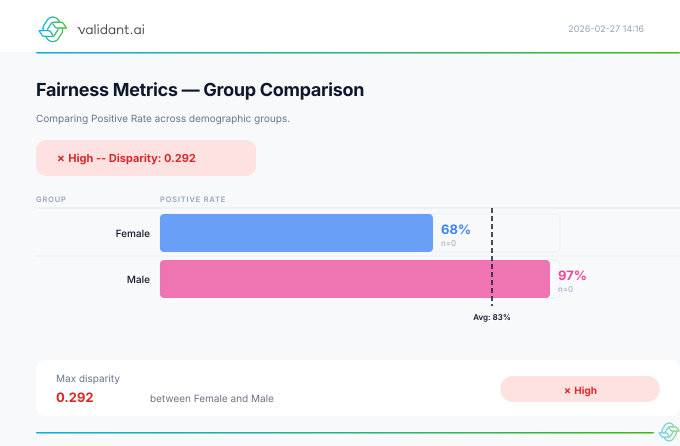

In [10]:
svg = group_comparison_to_svg(fair_report, metric='positive_rate')
print(f'group_comparison — {len(svg):,} bytes')
display(SVG(data=svg))

### 9 — Effect Sizes (`effect_sizes`)

**What it shows:** A lollipop chart of Cohen's d effect sizes. Each metric is a
horizontal line with a dot positioned left/right of center to indicate direction and
magnitude. Badges label each effect as Negligible, Small, Medium, or Large.
Summary stats show the maximum and average effect sizes.

**When to use:** To quantify the practical significance of fairness disparities, not
just statistical significance.

effect_sizes (with explanation) — 18,167 bytes


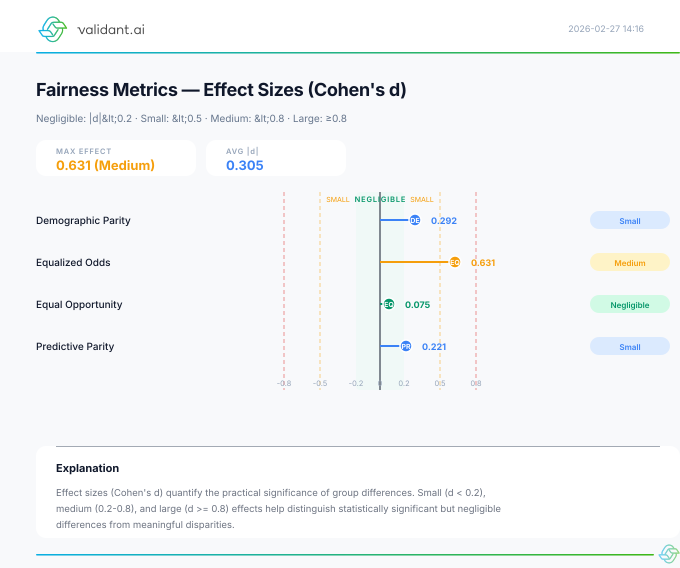

In [11]:
svg = effect_sizes_to_svg(
    fair_report,
    explanation=(
        "Effect sizes (Cohen's d) quantify the practical significance of group differences. "
        "Small (d < 0.2), medium (0.2-0.8), and large (d >= 0.8) effects help distinguish "
        "statistically significant but negligible differences from meaningful disparities."
    ),
)
print(f'effect_sizes (with explanation) — {len(svg):,} bytes')
display(SVG(data=svg))

### 10 — Confidence Intervals (`confidence_intervals`)

**What it shows:** A forest plot where each metric appears as a diamond (point estimate)
with horizontal whiskers (confidence interval bounds). A vertical dashed line at zero
indicates the "no disparity" reference. Red intervals are statistically significant
(CI excludes zero); blue intervals are not.

**When to use:** To assess the statistical reliability of fairness metric estimates and
decide whether observed disparities are likely real or due to sampling variation.

confidence_intervals — 17,777 bytes


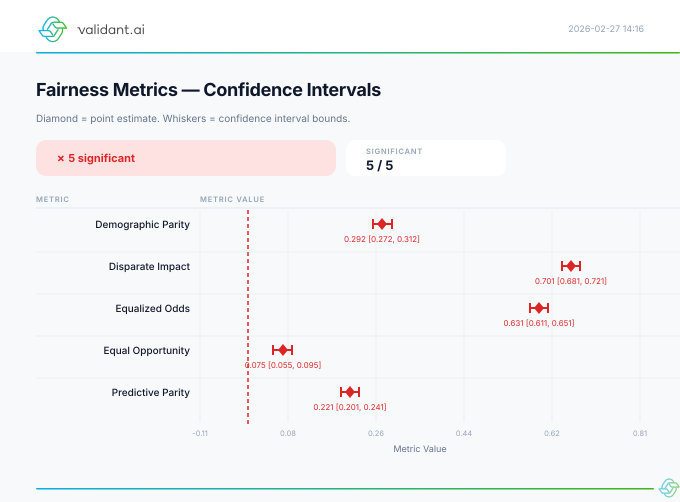

In [12]:
svg = confidence_intervals_to_svg(fair_report)
print(f'confidence_intervals — {len(svg):,} bytes')
display(SVG(data=svg))

---
## Calibration Visualizations

Four chart types for analysing prediction calibration and calibration fairness.

### 11 — Reliability Diagram (`reliability_diagram`)

**What it shows:** A calibration curve plotting predicted probability bins (x-axis) against
observed positive rates (y-axis). A dashed diagonal line represents perfect calibration.
An optional histogram shows the distribution of predictions. ECE and MCE badges provide
numeric calibration quality scores. A verdict badge (Well Calibrated / Moderate / Poorly
Calibrated) summarises the result.

**When to use:** To assess whether predicted probabilities match actual event frequencies.

reliability_diagram (with explanation) — 18,579 bytes


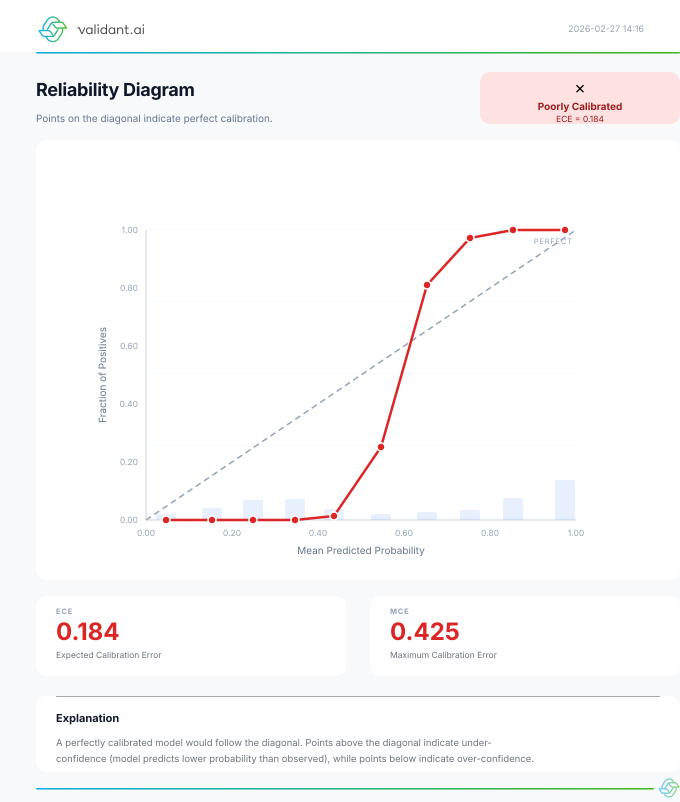

In [13]:
svg = reliability_diagram_to_svg(
    cal_y_true, cal_y_prob, n_bins=10, show_histogram=True,
    explanation=(
        "A perfectly calibrated model would follow the diagonal. Points above the "
        "diagonal indicate under-confidence (model predicts lower probability than "
        "observed), while points below indicate over-confidence."
    ),
)
print(f'reliability_diagram (with explanation) — {len(svg):,} bytes')
display(SVG(data=svg))

### 12 — Group Calibration (`group_calibration`)

**What it shows:** Multiple calibration curves overlaid on a single chart, one per
demographic group, each in a distinct colour. A legend identifies groups and their
individual ECE values. Summary badges show overall ECE and ECE disparity between groups.
A findings panel flags whether calibration disparity exists.

**When to use:** To check whether the model is equally well-calibrated across all
protected attribute groups.

group_calibration — 20,780 bytes


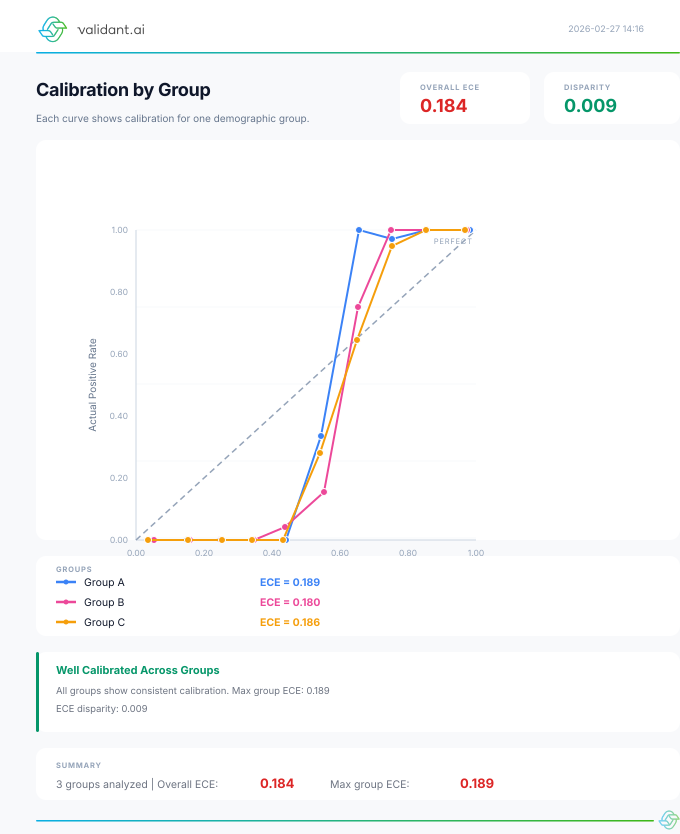

In [14]:
svg = group_calibration_to_svg(cal_y_true, cal_y_prob, cal_protected, n_bins=10)
print(f'group_calibration — {len(svg):,} bytes')
display(SVG(data=svg))

### 13 — Calibration Disparity (`calibration_disparity`)

**What it shows:** A bar chart comparing ECE values across groups. Each group gets a
coloured horizontal bar with its ECE value. Summary badges show the ECE disparity
(difference between worst and best groups), the disparity ratio, and identify best/worst
groups.

**When to use:** When you specifically need to quantify and compare calibration error
magnitudes across groups.

calibration_disparity (with explanation) — 16,702 bytes


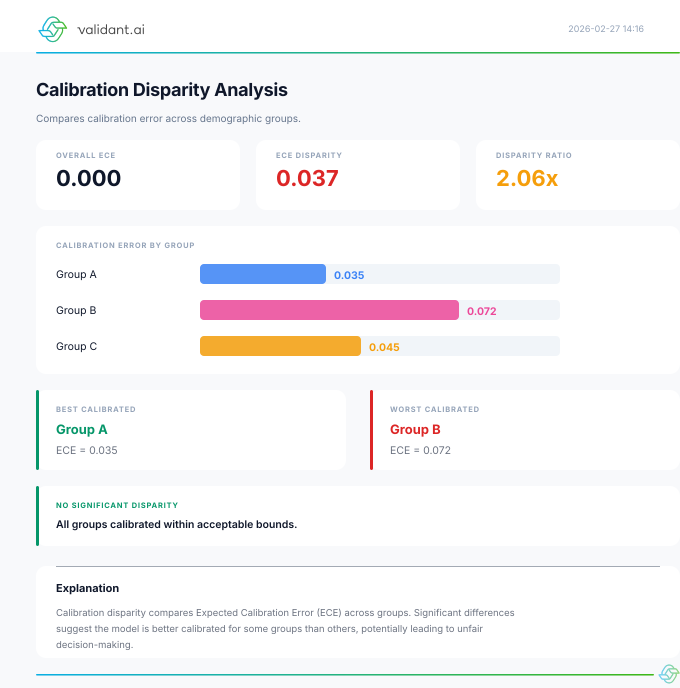

In [15]:
disparity_result = {
    'group_metrics': {
        'Group A': {'ece': 0.035, 'mce': 0.12, 'brier': 0.18},
        'Group B': {'ece': 0.072, 'mce': 0.21, 'brier': 0.24},
        'Group C': {'ece': 0.045, 'mce': 0.15, 'brier': 0.20},
    },
    'reference_group': 'Group A',
    'max_ece_disparity': 0.037,
    'max_mce_disparity': 0.09,
}
svg = calibration_disparity_to_svg(
    disparity_result,
    explanation=(
        "Calibration disparity compares Expected Calibration Error (ECE) across groups. "
        "Significant differences suggest the model is better calibrated for some groups "
        "than others, potentially leading to unfair decision-making."
    ),
)
print(f'calibration_disparity (with explanation) — {len(svg):,} bytes')
display(SVG(data=svg))

### 14 — Pareto Frontier (`pareto_frontier`)

**What it shows:** A scatter plot with calibration error on the x-axis and fairness
violation on the y-axis. Each dot is a model configuration. Red dots lie on the Pareto
frontier (non-dominated solutions); blue dots are dominated. A dashed line connects
the frontier points. Summary badges show the number of frontier points and the best
overall model.

**When to use:** When exploring the trade-off between calibration quality and fairness
to find the optimal operating point.

pareto_frontier — 17,937 bytes


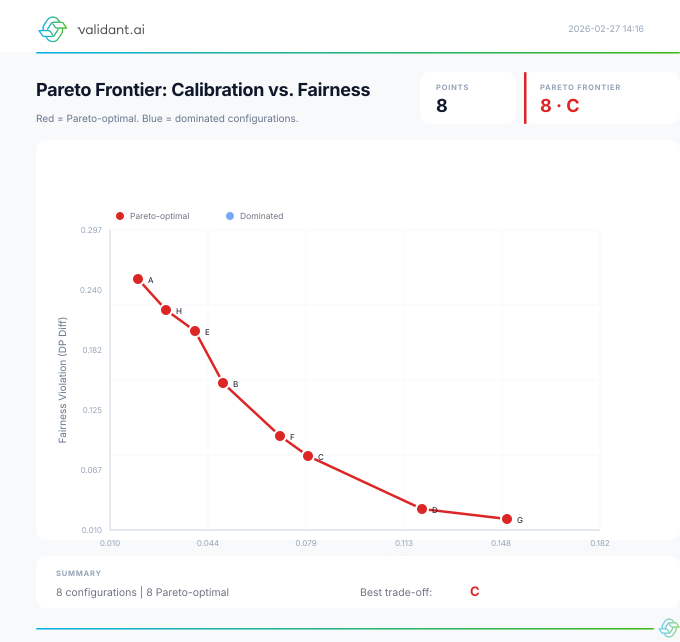

In [16]:
cal_errors = [0.02, 0.05, 0.08, 0.12, 0.04, 0.07, 0.15, 0.03]
fair_violations = [0.25, 0.15, 0.08, 0.03, 0.20, 0.10, 0.02, 0.22]
model_labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

svg = pareto_frontier_to_svg(
    cal_errors, fair_violations, labels=model_labels,
    x_label='Calibration Error (ECE)', y_label='Fairness Violation (DP Diff)',
)
print(f'pareto_frontier — {len(svg):,} bytes')
display(SVG(data=svg))

---
## Feature Engineering Visualizations

Four chart types for analysing feature–protected-attribute relationships.

### 15 — Correlation Heatmap (`correlation_heatmap`)

**What it shows:** A heatmap grid with features on rows and protected attributes on
columns. Cell colours indicate correlation strength: red = strong positive, blue =
strong negative, white/grey = near zero. Summary badges count the number of high
correlations above the threshold.

**When to use:** To identify which features are strongly correlated with protected
attributes and could act as proxies.

correlation_heatmap (with explanation) — 19,260 bytes


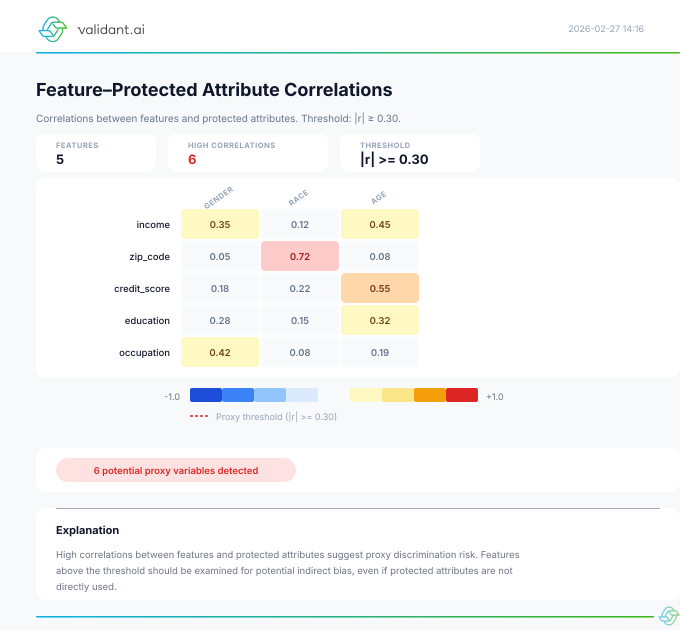

In [17]:
corr_matrix = SimpleNamespace(
    features=['income', 'zip_code', 'credit_score', 'education', 'occupation'],
    protected_attributes=['gender', 'race', 'age'],
    correlations={
        'income':       {'gender': 0.35, 'race': 0.12, 'age': 0.45},
        'zip_code':     {'gender': 0.05, 'race': 0.72, 'age': 0.08},
        'credit_score': {'gender': 0.18, 'race': 0.22, 'age': 0.55},
        'education':    {'gender': 0.28, 'race': 0.15, 'age': 0.32},
        'occupation':   {'gender': 0.42, 'race': 0.08, 'age': 0.19},
    },
)
svg = correlation_heatmap_to_svg(
    corr_matrix, threshold=0.3,
    explanation=(
        "High correlations between features and protected attributes suggest proxy "
        "discrimination risk. Features above the threshold should be examined for "
        "potential indirect bias, even if protected attributes are not directly used."
    ),
)
print(f'correlation_heatmap (with explanation) — {len(svg):,} bytes')
display(SVG(data=svg))

### 16 — Proxy Risk Assessment (`proxy_risk`)

**What it shows:** A ranked list of features that may serve as proxies for protected
attributes. Each feature shows a correlation bar and confidence bar, plus a risk-level
badge (HIGH / MEDIUM / LOW). Summary badges count features at each risk level.

**When to use:** After feature engineering to identify proxy variables that should be
removed, transformed, or monitored.

proxy_risk — 18,390 bytes


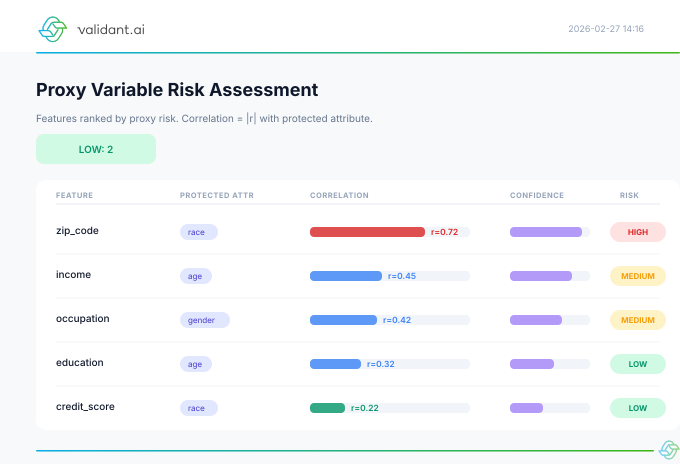

In [18]:
proxy_vars = [
    SimpleNamespace(feature='zip_code', protected_attribute='race',
                    correlation=0.72, risk_level=SimpleNamespace(value='high'),
                    confidence_score=0.91),
    SimpleNamespace(feature='income', protected_attribute='age',
                    correlation=0.45, risk_level=SimpleNamespace(value='medium'),
                    confidence_score=0.78),
    SimpleNamespace(feature='occupation', protected_attribute='gender',
                    correlation=0.42, risk_level=SimpleNamespace(value='medium'),
                    confidence_score=0.65),
    SimpleNamespace(feature='education', protected_attribute='age',
                    correlation=0.32, risk_level=SimpleNamespace(value='low'),
                    confidence_score=0.55),
    SimpleNamespace(feature='credit_score', protected_attribute='race',
                    correlation=0.22, risk_level=SimpleNamespace(value='low'),
                    confidence_score=0.42),
]
svg = proxy_risk_to_svg(proxy_vars)
print(f'proxy_risk — {len(svg):,} bytes')
display(SVG(data=svg))

### 17 — Transformation Comparison (`transformation_comparison`)

**What it shows:** Side-by-side before/after correlation bars for each feature.
Red bars = correlation before transformation, green bars = after. Percentage reduction
is shown per feature. A summary badge rates the overall effectiveness (Effective /
Moderate / Minimal) and shows the average correlation reduction.

**When to use:** To evaluate whether a fairness-aware feature transformation successfully
reduced proxy correlations.

transformation_comparison (with explanation) — 18,176 bytes


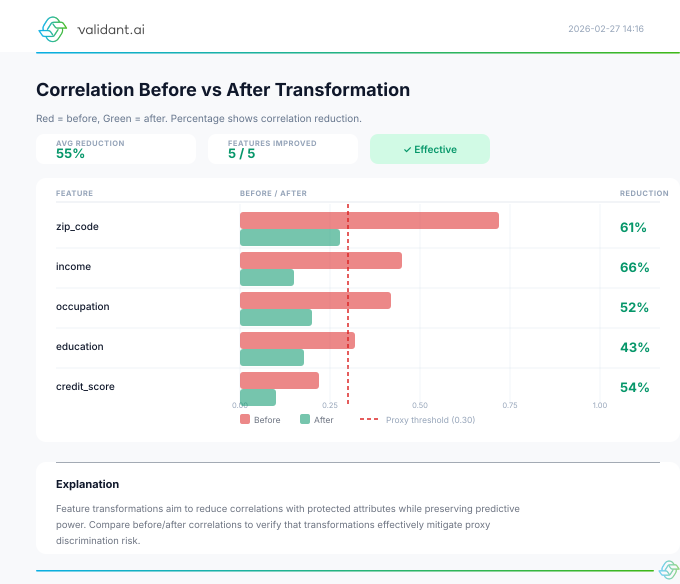

In [19]:
before = {'zip_code': 0.72, 'income': 0.45, 'occupation': 0.42,
          'education': 0.32, 'credit_score': 0.22}
after  = {'zip_code': 0.28, 'income': 0.15, 'occupation': 0.20,
          'education': 0.18, 'credit_score': 0.10}

svg = transformation_comparison_to_svg(
    before, after, threshold=0.3,
    explanation=(
        "Feature transformations aim to reduce correlations with protected attributes "
        "while preserving predictive power. Compare before/after correlations to verify "
        "that transformations effectively mitigate proxy discrimination risk."
    ),
)
print(f'transformation_comparison (with explanation) — {len(svg):,} bytes')
display(SVG(data=svg))

### 18 — Intersectional Analysis (`intersectional_analysis`)

**What it shows:** A two-dimensional heatmap where rows and columns represent two
different protected attributes (e.g. Race × Gender). Cell colour intensity reflects
the metric value (e.g. approval rate) for each intersection; sample counts are shown
in smaller text. A disparity badge highlights the maximum group difference.

**When to use:** To detect intersectional biases that may be invisible when analysing
single protected attributes in isolation.

intersectional_analysis — 18,783 bytes


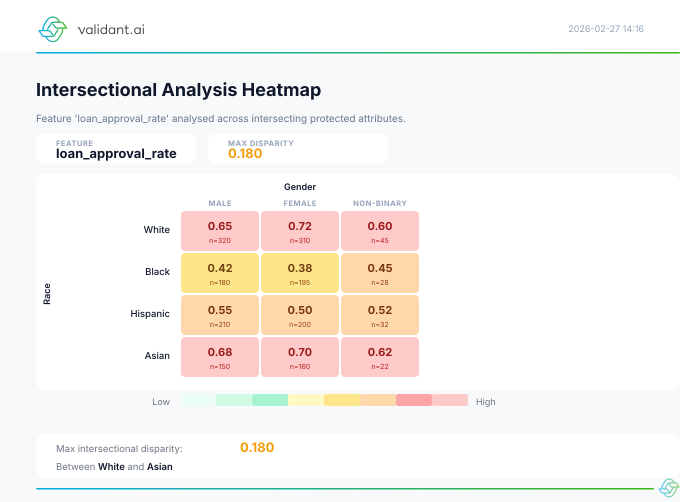

In [20]:
intersect_data = {
    'x_attr': 'Gender', 'y_attr': 'Race',
    'matrix': {
        'White':    {'Male': 0.65, 'Female': 0.72, 'Non-Binary': 0.60},
        'Black':    {'Male': 0.42, 'Female': 0.38, 'Non-Binary': 0.45},
        'Hispanic': {'Male': 0.55, 'Female': 0.50, 'Non-Binary': 0.52},
        'Asian':    {'Male': 0.68, 'Female': 0.70, 'Non-Binary': 0.62},
    },
    'counts': {
        'White':    {'Male': 320, 'Female': 310, 'Non-Binary': 45},
        'Black':    {'Male': 180, 'Female': 195, 'Non-Binary': 28},
        'Hispanic': {'Male': 210, 'Female': 200, 'Non-Binary': 32},
        'Asian':    {'Male': 150, 'Female': 160, 'Non-Binary': 22},
    },
}
svg = intersectional_analysis_to_svg(intersect_data, feature='loan_approval_rate')
print(f'intersectional_analysis — {len(svg):,} bytes')
display(SVG(data=svg))

---
## Training Visualizations

Four chart types for fairness-aware model training analysis.

In [21]:
# ── Mock training report data used by training templates ──

mock_method_comparisons = [
    SimpleNamespace(method_name='Baseline', accuracy=0.852, fairness_violation=0.185,
                    constraint_satisfied=False, training_time=2.1),
    SimpleNamespace(method_name='Reweighting', accuracy=0.834, fairness_violation=0.082,
                    constraint_satisfied=True, training_time=3.4),
    SimpleNamespace(method_name='Adversarial', accuracy=0.841, fairness_violation=0.065,
                    constraint_satisfied=True, training_time=8.7),
    SimpleNamespace(method_name='Constrained', accuracy=0.828, fairness_violation=0.041,
                    constraint_satisfied=True, training_time=5.2),
]

mock_tradeoff = {
    'all_results': [
        {'accuracy': 0.852, 'violation': 0.185, 'lambda': 0.0, 'satisfied': False},
        {'accuracy': 0.845, 'violation': 0.142, 'lambda': 0.1, 'satisfied': False},
        {'accuracy': 0.834, 'violation': 0.082, 'lambda': 0.3, 'satisfied': True},
        {'accuracy': 0.828, 'violation': 0.041, 'lambda': 0.5, 'satisfied': True},
        {'accuracy': 0.810, 'violation': 0.025, 'lambda': 0.8, 'satisfied': True},
        {'accuracy': 0.785, 'violation': 0.012, 'lambda': 1.0, 'satisfied': True},
    ],
    'pareto_frontier': [
        {'accuracy': 0.852, 'violation': 0.185},
        {'accuracy': 0.834, 'violation': 0.082},
        {'accuracy': 0.828, 'violation': 0.041},
        {'accuracy': 0.785, 'violation': 0.012},
    ],
    'best_fair': {'accuracy': 0.828, 'violation': 0.041},
    'best_accurate': {'accuracy': 0.852, 'violation': 0.185},
}

mock_training_report = SimpleNamespace(
    timestamp=datetime.now().strftime('%Y-%m-%d %H:%M'),
    task_type='binary_classification',
    data_info={'n_samples': 5000, 'n_groups': 3, 'n_features': 12, 'attribute_name': 'gender'},
    baseline_metrics={'accuracy': 0.852, 'fairness_violation': 0.185, 'constraint_satisfied': False},
    method_comparisons=mock_method_comparisons,
    recommendation=SimpleNamespace(
        recommended_method='Constrained',
        priority='high',
        rationale='Best fairness-accuracy trade-off with constraint satisfaction',
        alternative_methods=['Adversarial', 'Reweighting'],
    ),
    critical_issues=[
        {'type': 'fairness', 'description': 'Baseline violates demographic parity', 'severity': 'high'},
        {'type': 'data', 'description': 'Underrepresented group < 5% of data', 'severity': 'medium'},
    ],
    action_items=[
        'Apply constrained training method',
        'Collect more data for underrepresented group',
        'Monitor fairness metrics in production',
    ],
    tradeoff_analysis=mock_tradeoff,
    fairness_analysis={
        'constraint_type': 'demographic_parity',
        'base_rate_disparity': 0.12,
        'group_statistics': {
            'Male': {'size': 2750, 'proportion': 0.55, 'positive_rate': 0.72},
            'Female': {'size': 2000, 'proportion': 0.40, 'positive_rate': 0.58},
            'Non-binary': {'size': 250, 'proportion': 0.05, 'positive_rate': 0.61},
        },
    },
)

print('Mock training data ready')

Mock training data ready


### 19 — Training Report (`training_report`)

**What it shows:** A summary dashboard of fairness-aware training results. Includes
data-info cards (samples, groups, features), baseline accuracy and violation, a method
comparison table with accuracy/violation/status per method, the recommended method with
rationale, critical issues, and action items.

**When to use:** After running `FairnessTrainingAnalyzer` to get a quick summary of
which fairness method works best.

training_report (with explanation) — 21,485 bytes


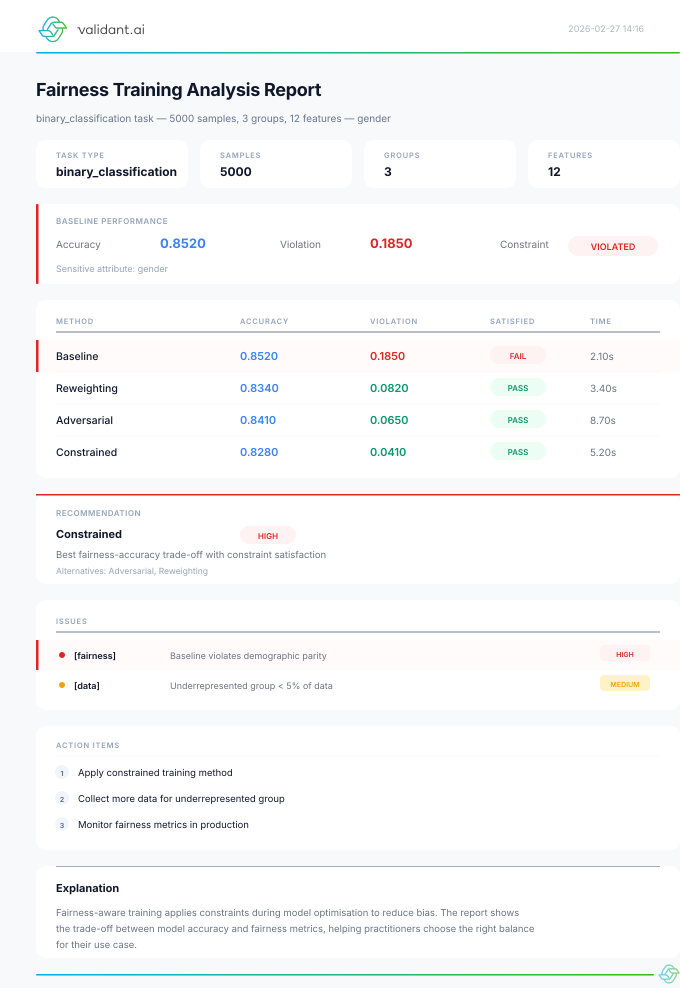

In [22]:
svg = training_report_to_svg(
    mock_training_report,
    explanation=(
        "Fairness-aware training applies constraints during model optimisation to reduce "
        "bias. The report shows the trade-off between model accuracy and fairness metrics, "
        "helping practitioners choose the right balance for their use case."
    ),
)
print(f'training_report (with explanation) — {len(svg):,} bytes')
display(SVG(data=svg))

### 20 — Training Analysis Report (`training_analysis_report`)

**What it shows:** A comprehensive full-page analysis report with all sections of a
FairnessTrainingReport: header with task type, data summary cards, baseline performance,
per-group positive-rate bars, method comparison bars with pass/fail badges, a trade-off
scatter plot (Pareto frontier overlay), critical issues with severity tags, and an
action-item checklist.

**When to use:** When you need a detailed, executive-level training fairness report.

training_analysis_report — 27,886 bytes


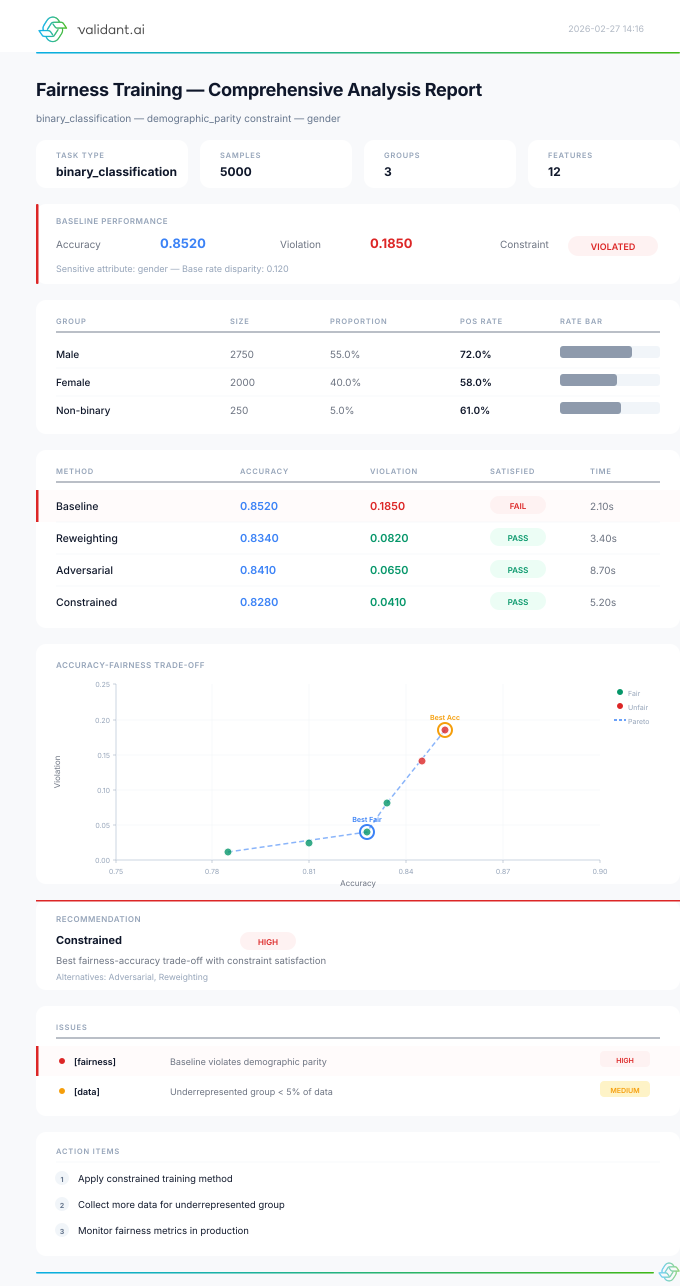

In [23]:
svg = training_analysis_report_to_svg(mock_training_report)
print(f'training_analysis_report — {len(svg):,} bytes')
display(SVG(data=svg))

### 21 — Method Comparison (`method_comparison`)

**What it shows:** A focused bar chart comparing fairness training methods. Each method
has two bars: one for accuracy and one for fairness violation, plus a constraint
satisfaction badge. Methods are ranked for easy visual comparison.

**When to use:** When you want a clean, focused comparison of training methods without
the full report context.

method_comparison (with explanation) — 17,478 bytes


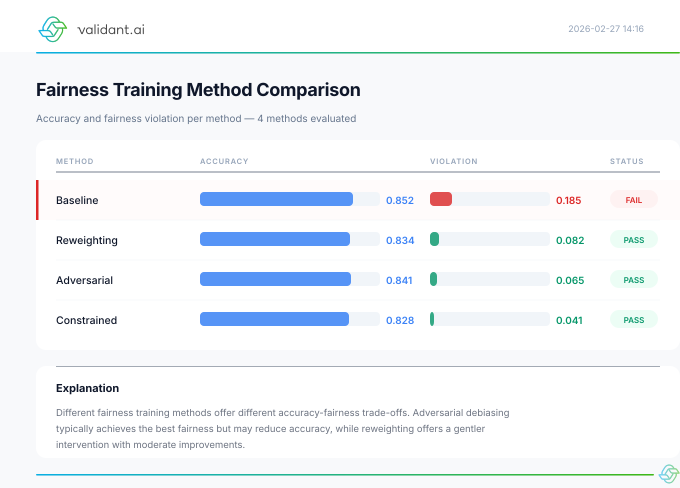

In [24]:
svg = method_comparison_to_svg(
    mock_method_comparisons,
    explanation=(
        "Different fairness training methods offer different accuracy-fairness trade-offs. "
        "Adversarial debiasing typically achieves the best fairness but may reduce accuracy, "
        "while reweighting offers a gentler intervention with moderate improvements."
    ),
)
print(f'method_comparison (with explanation) — {len(svg):,} bytes')
display(SVG(data=svg))

### 22 — Trade-off Analysis (`tradeoff_analysis`)

**What it shows:** A scatter plot with accuracy on one axis and fairness violation on the
other. Points represent different training configurations (varying the fairness penalty
lambda). Pareto-optimal points are highlighted, and the best fair and best accurate
configurations are marked. Green dots satisfy the constraint; red dots do not.

**When to use:** To explore the accuracy-fairness trade-off curve and choose an operating
point.

tradeoff_analysis — 18,078 bytes


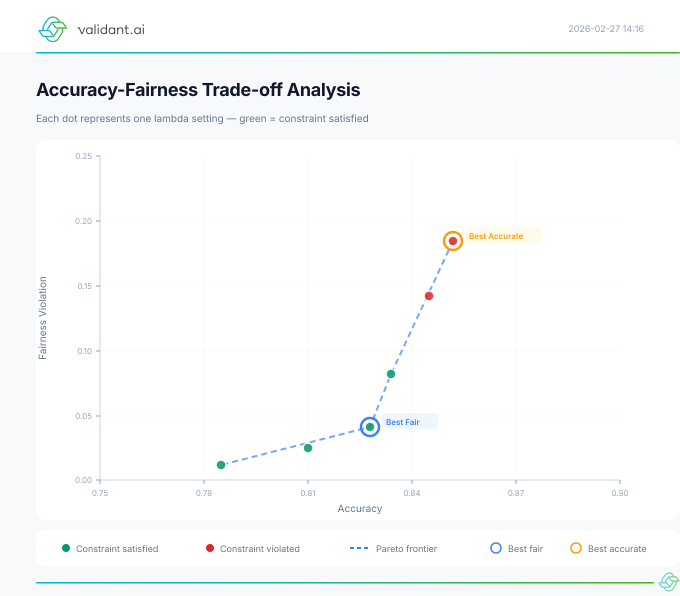

In [25]:
svg = tradeoff_analysis_to_svg(mock_tradeoff)
print(f'tradeoff_analysis — {len(svg):,} bytes')
display(SVG(data=svg))

---
## Post-Processing Visualizations

Three chart types for post-processing fairness interventions.

### 23 — Threshold Optimisation Report (`threshold_optimization_report`)

**What it shows:** Per-group threshold adjustments with before/after positive rates.
Each group shows its optimised threshold value and how the positive rate changed.
A fairness improvement panel shows original vs optimised disparity with reduction
percentage. An accuracy trade-off panel shows the cost in accuracy.

**When to use:** After running `GroupThresholdOptimizer` to visualise how group-specific
thresholds achieve fairness.

threshold_optimization_report (with explanation) — 18,844 bytes


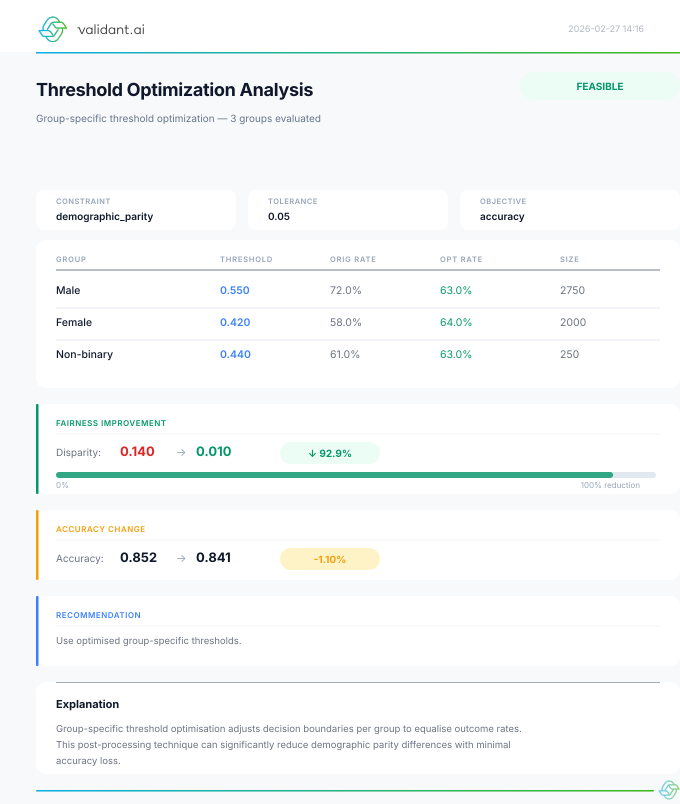

In [26]:
threshold_result = {
    'title': 'Threshold Optimization Analysis',
    'constraint_type': 'demographic_parity',
    'tolerance': 0.05,
    'original_threshold': 0.5,
    'groups': [
        {'name': 'Male', 'threshold': 0.55, 'original_rate': 0.72, 'optimized_rate': 0.63, 'size': 2750},
        {'name': 'Female', 'threshold': 0.42, 'original_rate': 0.58, 'optimized_rate': 0.64, 'size': 2000},
        {'name': 'Non-binary', 'threshold': 0.44, 'original_rate': 0.61, 'optimized_rate': 0.63, 'size': 250},
    ],
    'original_disparity': 0.14,
    'optimized_disparity': 0.01,
    'original_accuracy': 0.852,
    'optimized_accuracy': 0.841,
    'is_feasible': True,
    'recommendation': 'Use optimised group-specific thresholds.',
}

svg = threshold_optimization_to_svg(
    threshold_result,
    explanation=(
        "Group-specific threshold optimisation adjusts decision boundaries per group to "
        "equalise outcome rates. This post-processing technique can significantly reduce "
        "demographic parity differences with minimal accuracy loss."
    ),
)
print(f'threshold_optimization_report (with explanation) — {len(svg):,} bytes')
display(SVG(data=svg))

### 24 — Reweighting Comparison Report (`reweighting_comparison_report`)

**What it shows:** A comparison of prediction reweighting methods. Each method row
shows fairness improvement percentage, accuracy change, calibration change, and a
trade-off score. The best method is highlighted, and recommendations are listed.

**When to use:** After running `ReweightingAnalyzer.full_analysis()` to compare
different reweighting strategies.

reweighting_comparison_report — 16,948 bytes


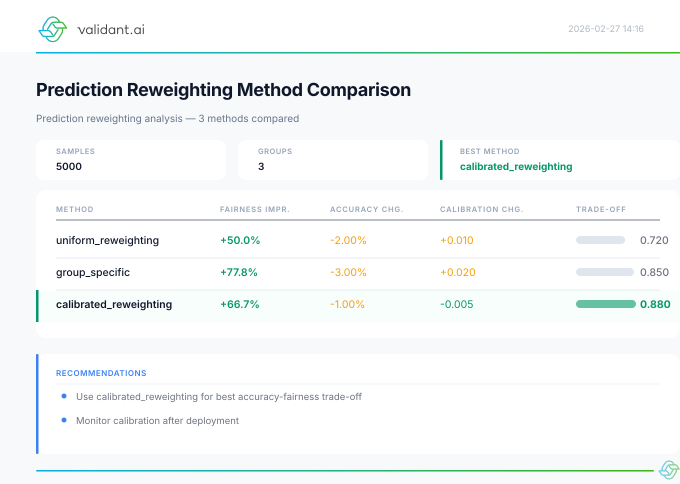

In [27]:
reweighting_report = {
    'metadata': {'n_samples': 5000, 'n_groups': 3},
    'method_results': [
        {
            'method': 'uniform_reweighting',
            'original_fairness': {'demographic_parity_diff': 0.18},
            'adjusted_fairness': {'demographic_parity_diff': 0.09},
            'original_performance': {'accuracy': 0.85},
            'adjusted_performance': {'accuracy': 0.83},
            'calibration_metrics': {'ece_change': 0.01},
            'trade_off_score': 0.72,
        },
        {
            'method': 'group_specific',
            'original_fairness': {'demographic_parity_diff': 0.18},
            'adjusted_fairness': {'demographic_parity_diff': 0.04},
            'original_performance': {'accuracy': 0.85},
            'adjusted_performance': {'accuracy': 0.82},
            'calibration_metrics': {'ece_change': 0.02},
            'trade_off_score': 0.85,
        },
        {
            'method': 'calibrated_reweighting',
            'original_fairness': {'demographic_parity_diff': 0.18},
            'adjusted_fairness': {'demographic_parity_diff': 0.06},
            'original_performance': {'accuracy': 0.85},
            'adjusted_performance': {'accuracy': 0.84},
            'calibration_metrics': {'ece_change': -0.005},
            'trade_off_score': 0.88,
        },
    ],
    'best_method': 'calibrated_reweighting',
    'recommendations': [
        'Use calibrated_reweighting for best accuracy-fairness trade-off',
        'Monitor calibration after deployment',
    ],
}

svg = reweighting_comparison_to_svg(reweighting_report)
print(f'reweighting_comparison_report — {len(svg):,} bytes')
display(SVG(data=svg))

### 25 — Detailed Fairness Report (`fairness_detailed_report`)

**What it shows:** An executive-level report with overall fairness score (percentage),
overall assessment badge (FAIR / MARGINAL / UNFAIR), a metrics table with values,
thresholds, and pass/fail, per-group statistics (size, positive rate, TPR, FPR),
pairwise group comparisons, key findings, and recommendations.

**When to use:** When you need a comprehensive, stakeholder-facing fairness report
that includes group-level detail and actionable recommendations.

fairness_detailed_report (with explanation) — 21,900 bytes


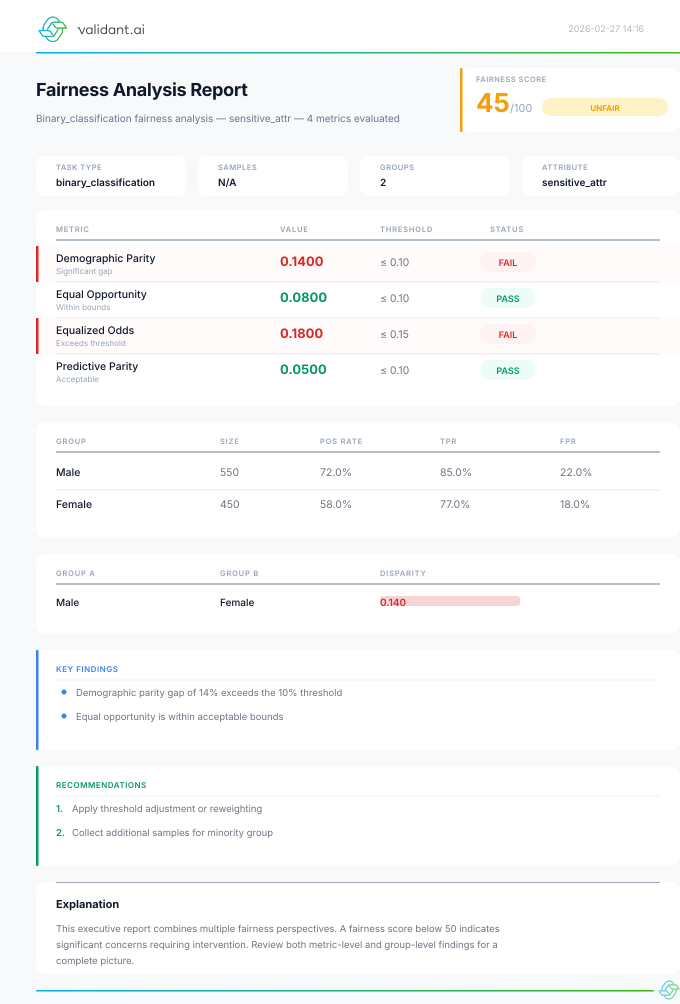

In [28]:
detailed_report = {
    'title': 'Fairness Analysis Report',
    'task_type': 'binary_classification',
    'assessment': {'fairness_score': 0.45},
    'metrics': {
        'demographic_parity': {'value': 0.14, 'threshold': 0.10, 'interpretation': 'Significant gap'},
        'equal_opportunity': {'value': 0.08, 'threshold': 0.10, 'interpretation': 'Within bounds'},
        'equalized_odds': {'value': 0.18, 'threshold': 0.15, 'interpretation': 'Exceeds threshold'},
        'predictive_parity': {'value': 0.05, 'threshold': 0.10, 'interpretation': 'Acceptable'},
    },
    'group_statistics': {
        'Male':   {'size': 550, 'positive_rate': 0.72, 'tpr': 0.85, 'fpr': 0.22},
        'Female': {'size': 450, 'positive_rate': 0.58, 'tpr': 0.77, 'fpr': 0.18},
    },
    'pairwise_comparisons': [
        {'group_a': 'Male', 'group_b': 'Female', 'disparity': 0.14},
    ],
    'key_findings': [
        'Demographic parity gap of 14% exceeds the 10% threshold',
        'Equal opportunity is within acceptable bounds',
    ],
    'recommendations': [
        'Apply threshold adjustment or reweighting',
        'Collect additional samples for minority group',
    ],
}

svg = fairness_detailed_report_to_svg(
    detailed_report,
    explanation=(
        "This executive report combines multiple fairness perspectives. A fairness score "
        "below 50 indicates significant concerns requiring intervention. Review both "
        "metric-level and group-level findings for a complete picture."
    ),
)
print(f'fairness_detailed_report (with explanation) — {len(svg):,} bytes')
display(SVG(data=svg))

---
## Monitoring & Operations Visualizations

Four chart types for production fairness monitoring.

In [29]:
# ── Mock monitoring data used by monitoring templates ──

now = datetime.now()

def make_window_metrics(ts, has_alert=False):
    """Create a mock WindowMetrics snapshot."""
    dp_val = np.random.uniform(0.04, 0.18)
    eo_val = np.random.uniform(0.03, 0.12)
    metrics = {
        'demographic_parity_diff': dp_val,
        'equal_opportunity_diff': eo_val,
        'predictive_parity_diff': np.random.uniform(0.02, 0.08),
    }
    alerts = {
        'demographic_parity_diff': dp_val > 0.12 or has_alert,
        'equal_opportunity_diff': eo_val > 0.10,
        'predictive_parity_diff': False,
    }
    return SimpleNamespace(
        timestamp=ts,
        metrics=metrics,
        alerts=alerts,
        any_alert=any(alerts.values()),
        sample_count=np.random.randint(800, 1200),
        group_rates={
            'gender': {
                'Male': np.random.uniform(0.60, 0.75),
                'Female': np.random.uniform(0.50, 0.65),
            },
        },
        mmd_scores={
            'gender': np.random.uniform(0.001, 0.08),
            'age': np.random.uniform(0.005, 0.15),
        },
    )

# Create a history of 10 monitoring snapshots
monitoring_history = [
    make_window_metrics(now - timedelta(hours=10 - i), has_alert=(i in [3, 7]))
    for i in range(10)
]
latest_window = monitoring_history[-1]

print(f'Monitoring history: {len(monitoring_history)} snapshots')
print(f'Latest: {latest_window.sample_count} samples, alert={latest_window.any_alert}')

Monitoring history: 10 snapshots
Latest: 819 samples, alert=True


### 26 — Monitoring Dashboard (`monitoring_dashboard`)

**What it shows:** A live dashboard for a single monitoring window. Includes a status
badge (OK / ALERT), a metrics table with value bars and alert badges, per-group positive
rate bars, and distribution shift (MMD) bars with STABLE/SHIFT badges. The header shows
timestamp, metric count, and sample count.

**When to use:** In production monitoring to get a snapshot of the current fairness state.

monitoring_dashboard — 17,527 bytes


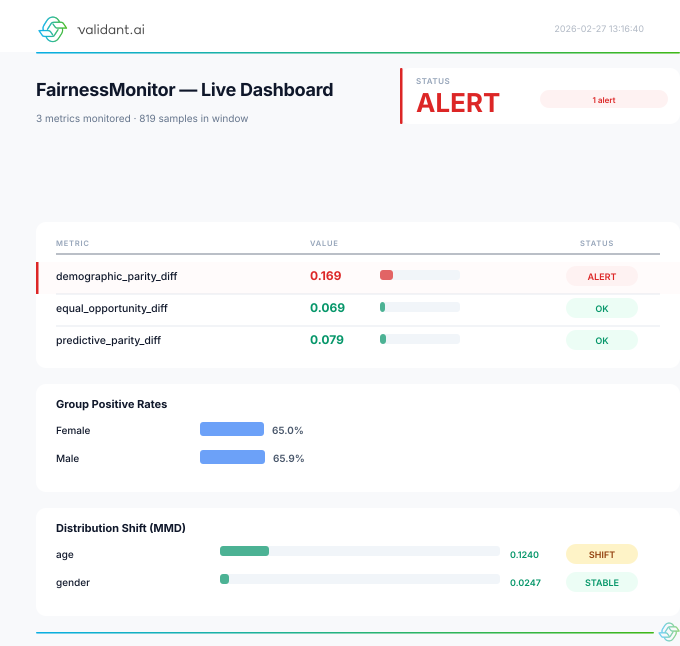

In [30]:
svg = monitoring_dashboard_to_svg(latest_window)
print(f'monitoring_dashboard — {len(svg):,} bytes')
display(SVG(data=svg))

### 27 — Drift Report (`drift_report`)

**What it shows:** A multi-scale drift analysis report. Each time scale (short-term,
medium-term, long-term) shows its drift score with a coloured bar, KS statistic,
p-value, mean shift, and drift-detected badge. An overall drift score badge appears
at the top.

**When to use:** After running `FairnessDriftDetector.check_drift()` to understand
whether fairness metrics are shifting over time and at which time scale.

drift_report (with explanation) — 17,721 bytes


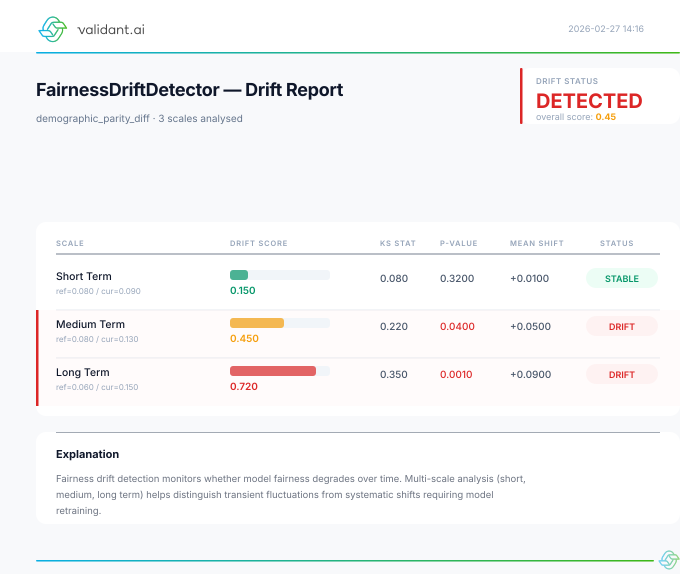

In [31]:
mock_drift = SimpleNamespace(
    drift_detected=True,
    overall_drift_score=0.45,
    metric='demographic_parity_diff',
    scales={
        'short_term': SimpleNamespace(
            drift_score=0.15, ks_statistic=0.08, p_value=0.32,
            mean_shift=0.01, reference_mean=0.08, current_mean=0.09,
            drift_detected=False,
        ),
        'medium_term': SimpleNamespace(
            drift_score=0.45, ks_statistic=0.22, p_value=0.04,
            mean_shift=0.05, reference_mean=0.08, current_mean=0.13,
            drift_detected=True,
        ),
        'long_term': SimpleNamespace(
            drift_score=0.72, ks_statistic=0.35, p_value=0.001,
            mean_shift=0.09, reference_mean=0.06, current_mean=0.15,
            drift_detected=True,
        ),
    },
)

svg = drift_report_to_svg(
    mock_drift,
    explanation=(
        "Fairness drift detection monitors whether model fairness degrades over time. "
        "Multi-scale analysis (short, medium, long term) helps distinguish transient "
        "fluctuations from systematic shifts requiring model retraining."
    ),
)
print(f'drift_report (with explanation) — {len(svg):,} bytes')
display(SVG(data=svg))

### 28 — Alert Timeline (`alert_timeline`)

**What it shows:** A chronological timeline of monitoring snapshots. Each row shows a
timestamp, sample count, number of alerts, and which metrics were flagged. Alert rows
are highlighted in red; clean rows in green. Summary badges at the top show total
snapshots, alerted windows, and clean windows.

**When to use:** To review the history of fairness alerts over time and identify
recurring patterns.

alert_timeline — 21,316 bytes


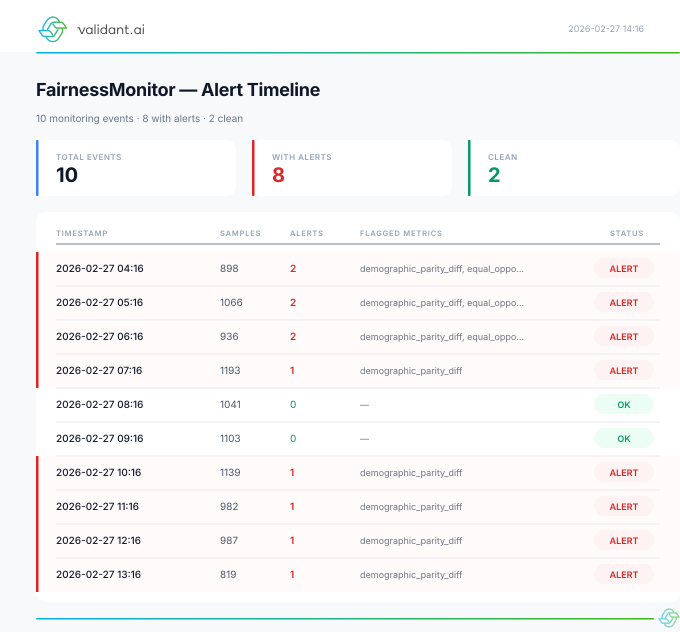

In [32]:
svg = alert_timeline_to_svg(monitoring_history)
print(f'alert_timeline — {len(svg):,} bytes')
display(SVG(data=svg))

### 29 — Temporal Analysis (`temporal_analysis`)

**What it shows:** Trend analysis for fairness metrics over time. For each metric, shows
mean, std, min/max range with a range bar, and trend direction with slope. A weekly
pattern bar chart (if available) reveals day-of-week effects. Trend summary rows show
direction (increasing / decreasing / stable) and degradation alerts.

**When to use:** When you have accumulated temporal fairness data and want to detect
trends, seasonal patterns, or progressive degradation.

temporal_analysis (with explanation) — 20,220 bytes


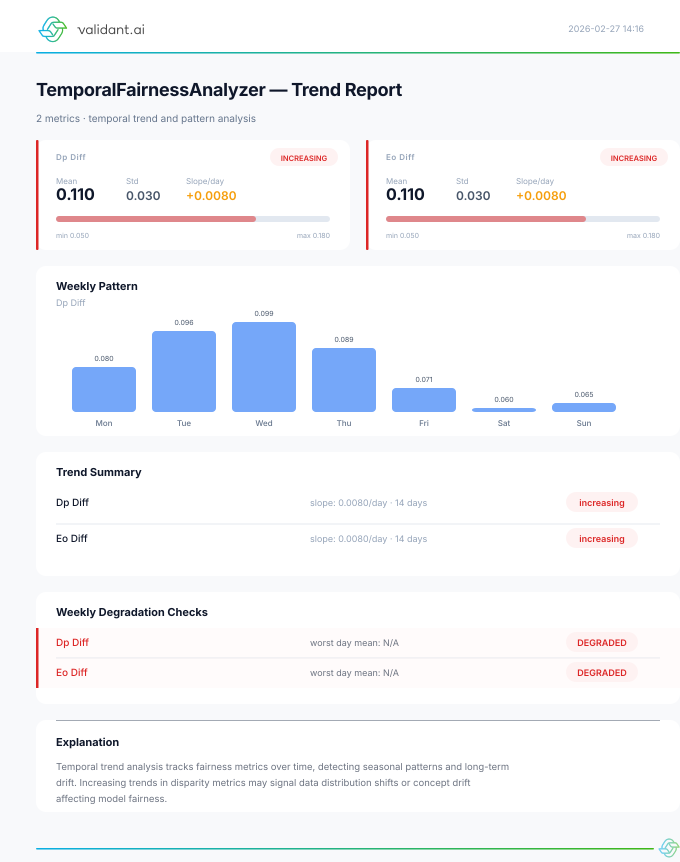

In [33]:
# TemporalFairnessAnalyzer requires a specific API; mock it with the expected methods.

class MockTemporalAnalyzer:
    """Minimal mock of TemporalFairnessAnalyzer for SVG rendering."""

    def to_dataframe(self):
        import pandas as pd
        return pd.DataFrame({
            'metric_name': ['dp_diff'] * 14 + ['eo_diff'] * 14,
            'value': np.random.uniform(0.05, 0.18, 28),
            'timestamp': [now - timedelta(days=i) for i in range(14)] * 2,
        })

    def get_metric_summary(self, name):
        return {
            'mean': 0.11, 'std': 0.03, 'min': 0.05, 'max': 0.18,
            'trend_direction': 'increasing', 'trend_slope': 0.008, 'n_days': 14,
        }

    def detect_seasonal_pattern(self, name, period=7):
        return {f'day_{i}': 0.08 + 0.02 * np.sin(i * 0.9) for i in range(period)}

    def detect_trend(self, name):
        return ('increasing', 0.008)

    def detect_weekly_degradation(self, name):
        return (True, 'Friday')


mock_temporal = MockTemporalAnalyzer()
svg = temporal_analysis_to_svg(
    mock_temporal, metric_names=['dp_diff', 'eo_diff'],
    explanation=(
        "Temporal trend analysis tracks fairness metrics over time, detecting seasonal "
        "patterns and long-term drift. Increasing trends in disparity metrics may signal "
        "data distribution shifts or concept drift affecting model fairness."
    ),
)
print(f'temporal_analysis (with explanation) — {len(svg):,} bytes')
display(SVG(data=svg))

---
## Experimentation & A/B Testing Visualizations

Three chart types for fairness-aware experimentation and statistical power analysis.

### 30 — Experiment Results (`experiment_results`)

**What it shows:** An A/B test results dashboard with the overall treatment effect and
confidence interval, a per-intersection effects table showing effect size (Cohen's d),
95% CI, p-value, sample sizes, and significance/power status. A forest plot visualises
effect sizes with CI whiskers across all intersections. A heterogeneity test panel
reports whether treatment effects vary significantly across groups. Power summary
shows how many intersections are adequately powered.

**When to use:** After running `FairnessExperiment.run_full_analysis()` to review
whether a treatment improves or harms fairness across demographic intersections.

experiment_results — 21,332 bytes


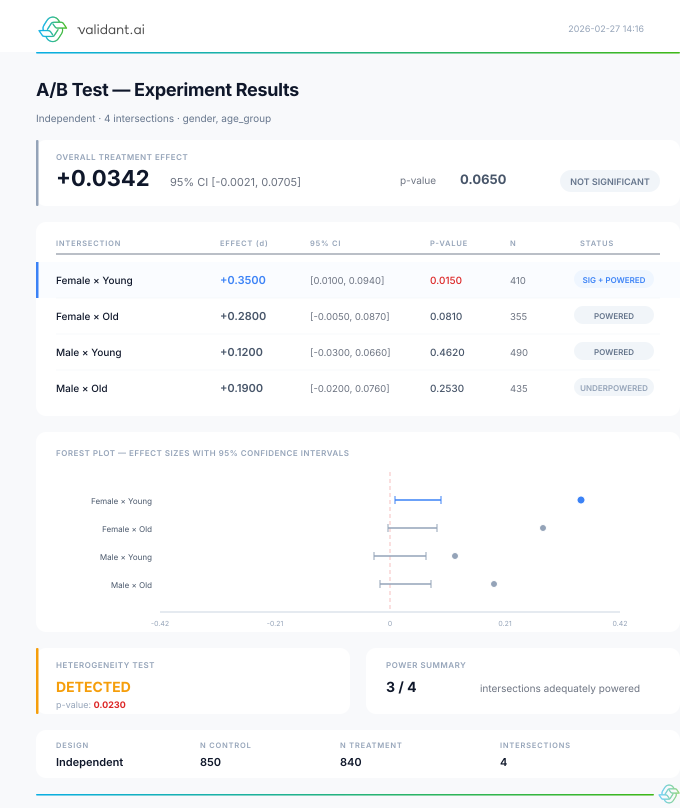

In [34]:
experiment_result_data = {
    'overall_effect': 0.0342,
    'overall_ci': (-0.0021, 0.0705),
    'overall_p_value': 0.065,
    'heterogeneity_detected': True,
    'heterogeneity_p_value': 0.023,
    'n_intersections': 4,
    'n_excluded': 0,
    'design_type': 'independent',
    'metadata': {'protected_attributes': ['gender', 'age_group']},
    'intersection_effects': [
        {'intersection': ('Female', 'Young'), 'effect': 0.052, 'effect_size_d': 0.35,
         'ci_lower': 0.01, 'ci_upper': 0.094, 'p_value': 0.015,
         'n_control': 200, 'n_treatment': 210, 'significant': True, 'powered': True},
        {'intersection': ('Female', 'Old'), 'effect': 0.041, 'effect_size_d': 0.28,
         'ci_lower': -0.005, 'ci_upper': 0.087, 'p_value': 0.081,
         'n_control': 180, 'n_treatment': 175, 'significant': False, 'powered': True},
        {'intersection': ('Male', 'Young'), 'effect': 0.018, 'effect_size_d': 0.12,
         'ci_lower': -0.03, 'ci_upper': 0.066, 'p_value': 0.462,
         'n_control': 250, 'n_treatment': 240, 'significant': False, 'powered': True},
        {'intersection': ('Male', 'Old'), 'effect': 0.028, 'effect_size_d': 0.19,
         'ci_lower': -0.02, 'ci_upper': 0.076, 'p_value': 0.253,
         'n_control': 220, 'n_treatment': 215, 'significant': False, 'powered': False},
    ],
}

svg = experiment_results_to_svg(experiment_result_data)
print(f'experiment_results — {len(svg):,} bytes')
display(SVG(data=svg))

### 31 — Experiment Recommendation (`experiment_recommendation`)

**What it shows:** A decision recommendation dashboard with a prominent decision badge
(Deploy Treatment / Keep Control / Extend Experiment / Investigate Further) and a
confidence gauge with percentage bar. Below, a reasoning section lists the factors that
led to the recommendation. A trade-offs table shows key metric impacts, and a caveats
panel flags risks. Summary metrics from the experiment appear at the bottom.

**When to use:** After running `ExperimentAnalysis.decision_recommendation()` to get an
actionable recommendation on whether to deploy, extend, or reject an experiment.

experiment_recommendation (with explanation) — 18,022 bytes


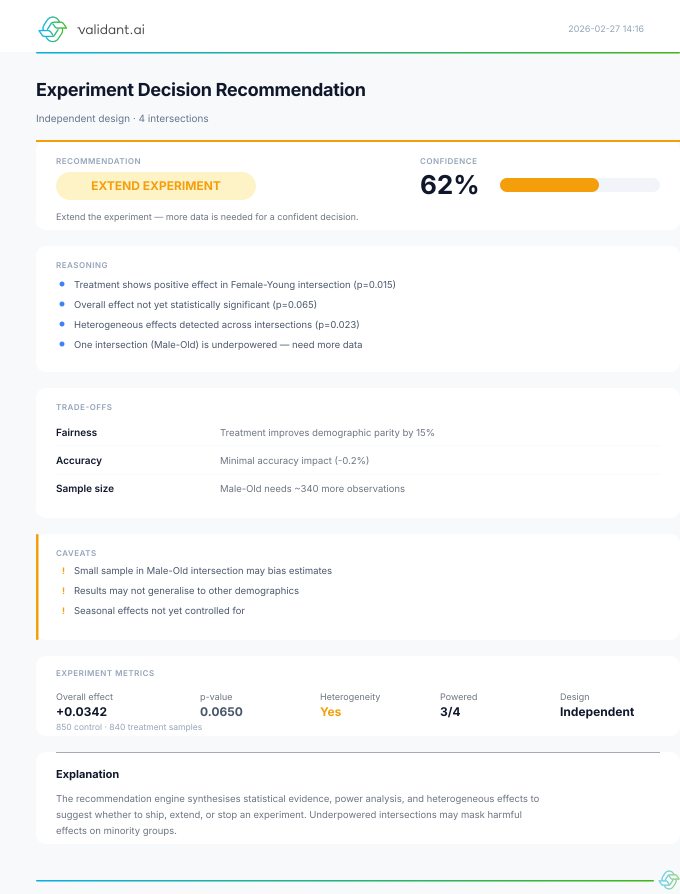

In [35]:
recommendation_data = {
    'decision': 'EXTEND_EXPERIMENT',
    'confidence': 0.62,
    'reasoning': [
        'Treatment shows positive effect in Female-Young intersection (p=0.015)',
        'Overall effect not yet statistically significant (p=0.065)',
        'Heterogeneous effects detected across intersections (p=0.023)',
        'One intersection (Male-Old) is underpowered — need more data',
    ],
    'trade_offs': {
        'Fairness': 'Treatment improves demographic parity by 15%',
        'Accuracy': 'Minimal accuracy impact (-0.2%)',
        'Sample size': 'Male-Old needs ~340 more observations',
    },
    'caveats': [
        'Small sample in Male-Old intersection may bias estimates',
        'Results may not generalise to other demographics',
        'Seasonal effects not yet controlled for',
    ],
}

svg = experiment_recommendation_to_svg(
    recommendation_data, experiment_result_data,
    explanation=(
        "The recommendation engine synthesises statistical evidence, power analysis, and "
        "heterogeneous effects to suggest whether to ship, extend, or stop an experiment. "
        "Underpowered intersections may mask harmful effects on minority groups."
    ),
)
print(f'experiment_recommendation (with explanation) — {len(svg):,} bytes')
display(SVG(data=svg))

### 32 — Power Analysis (`power_analysis`)

**What it shows:** A statistical power analysis dashboard with summary cards for powered
intersections count, average power, and total required sample size. A per-intersection
table shows power level (with mini bar), required N vs current N, effect size, and a
POWERED / NEEDS DATA badge. A bar chart visualises power across intersections with an
80% threshold line. A minimum detectable effect (MDE) panel shows the smallest effect
detectable at the given alpha and power target.

**When to use:** After running `FairnessPowerAnalyzer` to determine whether your experiment
has enough data to detect meaningful fairness effects in each demographic intersection.

power_analysis — 21,766 bytes


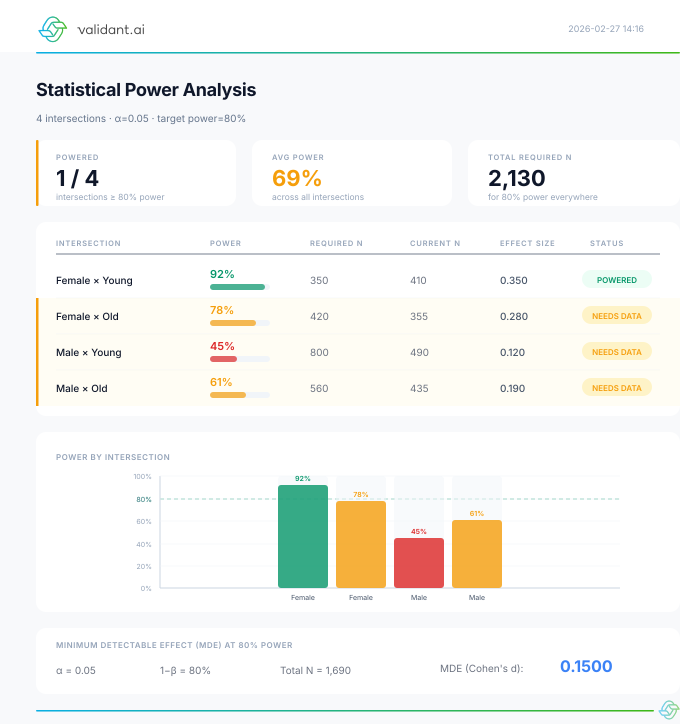

In [36]:
power_data = [
    {'intersection': ('Female', 'Young'), 'power': 0.92, 'required_n': 350,
     'is_powered': True, 'n_control': 200, 'n_treatment': 210, 'effect_size': 0.35},
    {'intersection': ('Female', 'Old'), 'power': 0.78, 'required_n': 420,
     'is_powered': False, 'n_control': 180, 'n_treatment': 175, 'effect_size': 0.28},
    {'intersection': ('Male', 'Young'), 'power': 0.45, 'required_n': 800,
     'is_powered': False, 'n_control': 250, 'n_treatment': 240, 'effect_size': 0.12},
    {'intersection': ('Male', 'Old'), 'power': 0.61, 'required_n': 560,
     'is_powered': False, 'n_control': 220, 'n_treatment': 215, 'effect_size': 0.19},
]

svg = power_analysis_to_svg(power_data, mde=0.15)
print(f'power_analysis — {len(svg):,} bytes')
display(SVG(data=svg))

---
## Workflow Integration Visualizations

Three templates for CI/CD workflow integration, hierarchical fairness gates, and
PR-ready report cards.

### 33 — Workflow Overview (`workflow_overview`)

**What it shows:** A development workflow integration pipeline overview showing
experiment tracking integrations (MLflow, W&B, auto-logging), version control
tools (pre-commit hooks, PR templates), and testing capabilities (pytest plugin,
assertion helpers, test suites). Each integration is displayed as a card with its
name, description, and status.

**When to use:** To visualise the full set of fairness workflow integrations available
in your ML pipeline, showing how experiment tracking, VCS hooks, and testing tools
connect together.

In [ ]:
svg = workflow_overview_to_svg(
    explanation=(
        "The workflow overview shows how vfairness integrates into the ML development "
        "lifecycle. Experiment trackers log fairness metrics alongside model performance; "
        "VCS hooks enforce fairness checks before code is merged; and pytest fixtures "
        "provide automated fairness assertions in CI pipelines."
    ),
)
print(f'workflow_overview (with explanation) — {len(svg):,} bytes')
display(SVG(data=svg))

### 34 — Hierarchical Gate (`hierarchical_gate`)

**What it shows:** A three-level hierarchical fairness gate visualization. Level 1
evaluates overall (all-groups) metrics; Level 2 evaluates single-attribute metrics
(e.g. gender, race); Level 3 evaluates intersectional metrics (e.g. gender x race).
Each level shows metric names, values, thresholds, and pass/fail badges. A warnings
panel flags small-sample intersections that may produce unreliable estimates.

**When to use:** After running `ModelFairnessGate.evaluate_hierarchical()` to inspect
which fairness levels passed and which intersections triggered warnings.

In [ ]:
svg = hierarchical_gate_to_svg(
    explanation=(
        "The hierarchical gate evaluates fairness at three levels of granularity: "
        "overall across all groups, per single protected attribute, and at the "
        "intersectional level. This layered approach catches disparities that "
        "single-attribute analysis might miss — a model can pass overall fairness "
        "checks while harming specific intersectional subgroups."
    ),
)
print(f'hierarchical_gate (with explanation) — {len(svg):,} bytes')
display(SVG(data=svg))

### 35 — Report Card (`report_card`)

**What it shows:** A PR-ready fairness report card summarising a gate decision.
Displays a prominent approved/blocked status badge, the model name, and a metrics
table showing each metric's value, threshold, pass/fail status, blocking flag, and
optional baseline comparison. A blocking reasons panel lists any reasons the gate
was blocked, and a warnings panel surfaces potential concerns.

**When to use:** To generate a concise, human-readable fairness summary for pull
requests, model registry entries, or stakeholder reviews after running
`ModelFairnessGate.evaluate()`.

In [ ]:
svg = report_card_to_svg(
    model_name='loan_approval_xgb_v2',
    explanation=(
        "The report card provides a concise, PR-ready summary of a model's fairness "
        "evaluation. It shows whether the model passed or failed the fairness gate, "
        "which metrics were blocking, and how current values compare to baseline. "
        "Attach this to pull requests or model registry entries for auditability."
    ),
)
print(f'report_card (with explanation) — {len(svg):,} bytes')
display(SVG(data=svg))

### 36 — Correlation Matrix (`correlation_matrix`)

**What it shows:** A general-purpose NxN correlation matrix with support for mixed
correlation methods (Pearson, Spearman, Cramér's V, point-biserial). Includes a
method legend, per-cell method indicator dots, and diagonal styling.

In [ ]:
# Build synthetic 5×5 mixed-method correlation matrix
corr_data = {
    'income':      {'income': 1.0, 'credit_score': 0.72, 'age': 0.35, 'education': 0.48, 'zip_code': -0.15},
    'credit_score':{'income': 0.72, 'credit_score': 1.0, 'age': 0.28, 'education': 0.55, 'zip_code': -0.08},
    'age':         {'income': 0.35, 'credit_score': 0.28, 'age': 1.0, 'education': 0.12, 'zip_code': 0.05},
    'education':   {'income': 0.48, 'credit_score': 0.55, 'age': 0.12, 'education': 1.0, 'zip_code': -0.22},
    'zip_code':    {'income': -0.15, 'credit_score': -0.08, 'age': 0.05, 'education': -0.22, 'zip_code': 1.0},
}
methods = {
    'income':      {'income': 'pearson', 'credit_score': 'pearson', 'age': 'pearson', 'education': 'point-biserial', 'zip_code': 'cramers_v'},
    'credit_score':{'income': 'pearson', 'credit_score': 'pearson', 'age': 'pearson', 'education': 'point-biserial', 'zip_code': 'cramers_v'},
    'age':         {'income': 'pearson', 'credit_score': 'pearson', 'age': 'pearson', 'education': 'spearman', 'zip_code': 'cramers_v'},
    'education':   {'income': 'point-biserial', 'credit_score': 'point-biserial', 'age': 'spearman', 'education': 'cramers_v', 'zip_code': 'cramers_v'},
    'zip_code':    {'income': 'cramers_v', 'credit_score': 'cramers_v', 'age': 'cramers_v', 'education': 'cramers_v', 'zip_code': 'cramers_v'},
}
svg = correlation_matrix_to_svg(
    corr_data, methods=methods, threshold=0.5,
    explanation=(
        "The general correlation matrix shows associations between all feature pairs, "
        "automatically selecting the appropriate method for each data type. High correlations "
        "above the threshold may indicate redundant features or proxy variables."
    ),
)
display(SVG(svg))

### 37 — Causal Decomposition (`causal_decomposition`)

**What it shows:** A causal mediation analysis breakdown with direct vs indirect
effects, Baron–Kenny steps, temporal stability chart, and mediation proportion.

In [ ]:
svg = causal_decomposition_to_svg(
    explanation=(
        "Causal decomposition uses mediation analysis to separate the total disparity "
        "into direct and indirect effects. The Baron-Kenny four-step test validates "
        "the causal pathway through intermediate variables."
    ),
)
display(SVG(svg))

### 38 — Robustness Testing (`robustness_testing`)

**What it shows:** Permutation test results, sensitivity analysis under perturbations,
and subgroup audit findings including gerrymandering detection.

In [ ]:
svg = robustness_testing_to_svg(
    explanation=(
        "Robustness testing verifies that fairness conclusions are stable under "
        "permutation tests, data perturbations, and fine-grained subgroup analysis. "
        "Flagged subgroups may indicate gerrymandering risks."
    ),
)
display(SVG(svg))

### 39 — Ranking Fairness (`ranking_fairness`)

**What it shows:** Exposure parity, NDKL, and attention fairness metrics for ranking
systems. Includes per-group position distribution and metric pass/fail badges.

In [ ]:
svg = ranking_fairness_to_svg(
    explanation=(
        "Ranking fairness evaluates whether different demographic groups receive "
        "equitable exposure in ranked lists. Metrics include exposure parity, "
        "normalized discounted KL-divergence, and attention fairness."
    ),
)
display(SVG(svg))

### 40 — Data Validation (`data_validation`)

**What it shows:** Pre-training data quality checks with severity-coded issues
(critical, warning, info), affected groups, and actionable recommendations.

In [ ]:
svg = data_validation_to_svg(
    explanation=(
        "Data validation runs automated checks on training data before model "
        "fitting. Issues are categorised by severity (CRITICAL, WARNING, INFO) "
        "and linked to specific demographic groups that may be affected."
    ),
)
display(SVG(svg))

### 41 — Auto Discovery (`auto_discovery`)

**What it shows:** Automatically discovered protected attribute candidates,
fairness violations per attribute, and intersectional group advantage analysis.

In [ ]:
svg = auto_discovery_to_svg(
    explanation=(
        "Auto discovery scans the feature space to identify potential protected "
        "attributes and their intersections. It flags fairness violations and "
        "highlights groups with disproportionate advantage or disadvantage."
    ),
)
display(SVG(svg))

### 42 — Regression Fairness (`regression_fairness`)

**What it shows:** Group-level regression metrics (MAE, RMSE, R²), disparity badges,
Cohen's d effect sizes as lollipop chart, residual bias bars, and recommendations.

In [ ]:
svg = regression_fairness_to_svg(
    explanation=(
        "Regression fairness assesses whether predictive models produce equitable "
        "error distributions across demographic groups. Effect sizes quantify the "
        "practical significance of inter-group prediction gaps."
    ),
)
display(SVG(svg))

### 43 — Reporting Dashboard (`reporting_dashboard`)

**What it shows:** A multi-tier fairness report dashboard with health score gauge,
metric status grid, active alerts, and recommendations. Supports executive,
operational, and technical tiers.

In [ ]:
svg = reporting_dashboard_to_svg(
    tier='operational',
    explanation=(
        "The reporting dashboard provides a real-time fairness health overview "
        "tailored to different stakeholder tiers. The operational tier shows "
        "metric-level detail, active alerts, and actionable recommendations."
    ),
)
display(SVG(svg))

---
## Summary & Export

In [ ]:
templates = list_templates()

print('=' * 60)
print(f'ALL {len(templates)} SVG TEMPLATES DEMONSTRATED')
print('=' * 60)
print()
print('Report Dashboards (4):')
print('  - bias_audit              Comprehensive multi-module bias audit')
print('  - calibration_report      Overall + per-group calibration analysis')
print('  - fairness_report         Metric card grid with pass/fail badges')
print('  - cicd_pipeline           CI/CD pipeline gate report')
print()
print('Fairness Metrics (6):')
print('  - radar_chart             Spider polygon chart of metric scores')
print('  - disparity_heatmap       Group x metric heatmap')
print('  - metrics_bar_chart       Horizontal bars with thresholds')
print('  - group_comparison        Per-group outcome comparison')
print('  - effect_sizes            Cohen d lollipop chart')
print('  - confidence_intervals    Forest plot with CI whiskers')
print()
print('Calibration (4):')
print('  - reliability_diagram     Calibration curve + histogram')
print('  - group_calibration       Per-group calibration curves')
print('  - calibration_disparity   ECE comparison across groups')
print('  - pareto_frontier         Calibration vs fairness scatter')
print()
print('Feature Engineering (5):')
print('  - correlation_heatmap     Feature x protected-attr correlations')
print('  - correlation_matrix      General NxN multi-method matrix')
print('  - proxy_risk              Proxy variable risk assessment')
print('  - transformation_comparison  Before / after correlation reduction')
print('  - intersectional_analysis 2D intersection heatmap')
print()
print('Training (4):')
print('  - training_report         Fairness training summary dashboard')
print('  - training_analysis_report  Full-page analysis report')
print('  - method_comparison       Method accuracy / fairness bars')
print('  - tradeoff_analysis       Accuracy-fairness scatter + Pareto')
print()
print('Post-Processing (3):')
print('  - threshold_optimization_report  Group threshold adjustments')
print('  - reweighting_comparison_report  Reweighting method comparison')
print('  - fairness_detailed_report       Executive fairness report')
print()
print('Monitoring (4):')
print('  - monitoring_dashboard    Live fairness monitoring snapshot')
print('  - drift_report            Multi-scale drift analysis')
print('  - alert_timeline          Chronological alert history')
print('  - temporal_analysis       Trend and pattern analysis')
print()
print('Experimentation & A/B Testing (4):')
print('  - experiment_results      A/B test results with forest plot')
print('  - experiment_recommendation  Decision recommendation dashboard')
print('  - power_analysis          Statistical power analysis report')
print('  - causal_decomposition    Causal mediation analysis breakdown')
print()
print('Workflow Integration (3):')
print('  - workflow_overview       Development workflow integration pipeline')
print('  - hierarchical_gate       Three-level hierarchical fairness gate')
print('  - report_card             PR-ready fairness report card')
print()
print('Advanced Modules (6):')
print('  - robustness_testing      Permutation tests & sensitivity analysis')
print('  - ranking_fairness        Exposure parity & ranking metrics')
print('  - data_validation         Pre-training data quality checks')
print('  - auto_discovery          Protected attribute auto-detection')
print('  - regression_fairness     Regression equity & effect sizes')
print('  - reporting_dashboard     Multi-tier fairness health dashboard')

In [ ]:
# ── Save all rendered SVGs to output/ directory ──
os.makedirs('output/svg-templates', exist_ok=True)

# Re-render every template and save
all_svgs = {
    # Report dashboards
    'bias_audit': report.to_svg(),
    'calibration_report': cal_report.to_svg(),
    'fairness_report': fair_analyzer.report_to_svg(),
    'cicd_pipeline': cicd_pipeline_to_svg(
        validation_result=validation, test_results=tests, gate_decision=gate),
    # Fairness metrics
    'radar_chart': radar_chart_to_svg(fair_report),
    'disparity_heatmap': disparity_heatmap_to_svg(fair_report),
    'metrics_bar_chart': metrics_bar_chart_to_svg(fair_report),
    'group_comparison': group_comparison_to_svg(fair_report, metric='positive_rate'),
    'effect_sizes': effect_sizes_to_svg(fair_report),
    'confidence_intervals': confidence_intervals_to_svg(fair_report),
    # Calibration
    'reliability_diagram': reliability_diagram_to_svg(cal_y_true, cal_y_prob, n_bins=10),
    'group_calibration': group_calibration_to_svg(cal_y_true, cal_y_prob, cal_protected, n_bins=10),
    'calibration_disparity': calibration_disparity_to_svg(disparity_result),
    'pareto_frontier': pareto_frontier_to_svg(
        cal_errors, fair_violations, labels=model_labels),
    # Feature engineering
    'correlation_heatmap': correlation_heatmap_to_svg(corr_matrix, threshold=0.3),
    'proxy_risk': proxy_risk_to_svg(proxy_vars),
    'transformation_comparison': transformation_comparison_to_svg(before, after, threshold=0.3),
    'intersectional_analysis': intersectional_analysis_to_svg(intersect_data, feature='loan_approval_rate'),
    # Training
    'training_report': training_report_to_svg(mock_training_report),
    'training_analysis_report': training_analysis_report_to_svg(mock_training_report),
    'method_comparison': method_comparison_to_svg(mock_method_comparisons),
    'tradeoff_analysis': tradeoff_analysis_to_svg(mock_tradeoff),
    # Post-processing
    'threshold_optimization_report': threshold_optimization_to_svg(threshold_result),
    'reweighting_comparison_report': reweighting_comparison_to_svg(reweighting_report),
    'fairness_detailed_report': fairness_detailed_report_to_svg(detailed_report),
    # Monitoring
    'monitoring_dashboard': monitoring_dashboard_to_svg(latest_window),
    'drift_report': drift_report_to_svg(mock_drift),
    'alert_timeline': alert_timeline_to_svg(monitoring_history),
    'temporal_analysis': temporal_analysis_to_svg(mock_temporal, metric_names=['dp_diff', 'eo_diff']),
    # Experimentation & A/B Testing
    'experiment_results': experiment_results_to_svg(experiment_result_data),
    'experiment_recommendation': experiment_recommendation_to_svg(recommendation_data, experiment_result_data),
    'power_analysis': power_analysis_to_svg(power_data, mde=0.15),
    # Workflow Integration
    'workflow_overview': workflow_overview_to_svg(),
    'hierarchical_gate': hierarchical_gate_to_svg(),
    'report_card': report_card_to_svg(model_name='loan_approval_xgb_v2'),
    # Feature engineering (additional)
    'correlation_matrix': correlation_matrix_to_svg(corr_data, methods=methods, threshold=0.5),
    # Experimentation (additional)
    'causal_decomposition': causal_decomposition_to_svg(),
    # Advanced modules
    'robustness_testing': robustness_testing_to_svg(),
    'ranking_fairness': ranking_fairness_to_svg(),
    'data_validation': data_validation_to_svg(),
    'auto_discovery': auto_discovery_to_svg(),
    'regression_fairness': regression_fairness_to_svg(),
    'reporting_dashboard': reporting_dashboard_to_svg(tier='operational'),
}

for name, svg_str in all_svgs.items():
    path = f'output/svg-templates/{name}.svg'
    with open(path, 'w') as f:
        f.write(svg_str)
    print(f'  {name:40s}  {len(svg_str):>6,} bytes')

print(f'\nSaved {len(all_svgs)} SVG files to output/svg-templates/')